In [2]:
%load_ext autoreload
%autoreload 2

In [1]:
import gc
import numpy as np
import os
import re
import sys

import pandas as pd
import tensorflow_data_validation as tfdv

#VERSION = "20221025"
DATA_DIR = r"Z:\13.Data Science\Projects\2022_GI_Xsell\Data"
PROJECT_DIR = "../"
RAW_DATA_DIR = os.path.join(DATA_DIR, "raw")
PROCESSED_DATA_DIR = os.path.join(DATA_DIR, "processed")
META_DATA_DIR = os.path.join(DATA_DIR, "meta_and_reference_data")
VER_1025_DIR = os.path.join(RAW_DATA_DIR, "20221025")
VER_1118_DIR = os.path.join(RAW_DATA_DIR, "20221118")
VER_1122_DIR = os.path.join(RAW_DATA_DIR, "20221122")
VER_1212_DIR = os.path.join(RAW_DATA_DIR, "20221212")
GI_DATA_DIR = os.path.join(RAW_DATA_DIR, "GI")
PA_DATA_DIR = os.path.join(GI_DATA_DIR, "Travel", "202210")
sys.path.insert(0, DATA_DIR)
sys.path.insert(0, PROJECT_DIR)

from datetime import datetime
from dateutil.relativedelta import relativedelta

from src.utils.common import PLAN_TYPE_LST, WGP_LST, INFORCE_STATUS_LST
from src.utils.helper_function import find_plan_type, one_hot

In [2]:
pd.set_option('display.width', None)
pd.set_option('max_colwidth', None)
# pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [3]:
BASESTAT_FILE = os.path.join(PA_DATA_DIR, "basestat.parquet")
CLAMBASE_FILE = os.path.join(PA_DATA_DIR, "clambase.parquet")
PREMBASE_FILE = os.path.join(PA_DATA_DIR, "prembase.parquet")
CLIENT_DATA_MAPPING_FILE = os.path.join(PROCESSED_DATA_DIR, "processed_client_data.parquet")

## import prembase file

In [4]:
prembase_df = pd.read_parquet(PREMBASE_FILE)

# convert column CCDATE, TRANDATE to datetime at prembase_df
prembase_df["OCCDATE"] = pd.to_datetime(prembase_df["OCCDATE"], format="%Y%m%d")
prembase_df["TRANDATE"] = pd.to_datetime(prembase_df["TRANDATE"], format="%Y%m%d")

## primary numbers

In [5]:
print("prembase_df shape:", prembase_df.shape)
print("number of policies:", prembase_df['contrnb'].nunique())
print("number of unique clients (using client no.):", prembase_df['COWNNUM'].nunique())

prembase_df shape: (4844657, 79)
number of policies: 2421762
number of unique clients (using client no.): 1499865


## check date distribution of each policy by latest cc_date

### distribution by OCCDATE

<AxesSubplot:>

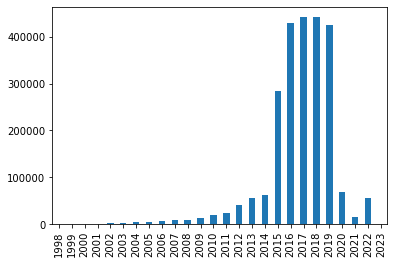

In [6]:
# convert column OCCDATE to datetime at prembase_df
prembase_df["OCCDATE"] = pd.to_datetime(prembase_df["OCCDATE"], format="%Y%m%d")

# assign OCCDATE_year as year of OCCDATE
prembase_df["OCCDATE_year"] = prembase_df["OCCDATE"].dt.year

# plot the year distribution of each distinct contrnb at prembase_df
prembase_df.drop_duplicates(subset=["contrnb"])["OCCDATE_year"].value_counts().sort_index().plot(kind="bar")

### filter prembase_df by observed OCCDATE_year (2002/ 2009/ 2015?)

In [7]:
print("before filter by 19970101:", prembase_df.shape)

# keep prembase_df with OCCDATE >= 2002-01-01
prembase_df = prembase_df[prembase_df["OCCDATE"] >= pd.to_datetime(20020101, format="%Y%m%d")]

print("after filter by 20020101:", prembase_df.shape)

before filter by 19970101: (4844657, 80)
after filter by 20020101: (4787992, 80)


## output descriptive stat

In [8]:
# stat df for output

prembase_stat_df = pd.DataFrame()
prembase_stat_df["col"] = prembase_df.columns

# prembase_des generated using describe()

prembase_des = prembase_df.describe().transpose()
prembase_des.head()

# merge prembase_des with prembase_stat_df

prembase_stat_df = prembase_stat_df.merge(prembase_des, left_on="col", right_index=True, how="left")
prembase_stat_df.head()

# add missing % to prembase_stat_df

prembase_stat_df["missing"] = (prembase_df.isna().sum()/ prembase_df.shape[0]).values

# add nunique to prembase_stat_df

prembase_stat_df["nunique"] = prembase_df.nunique().values

# add 0 % to prembase_stat_df
# ((prembase_df==0) | (prembase_df=="0") | (prembase_df==b"0")

prembase_stat_df["zeros"] = (((prembase_df==0) | (prembase_df=="0")).sum(axis=0) / prembase_df.shape[0]).values

# mode_df generated using mode()

mode_df = prembase_df.mode().transpose()
mode_df.head()

# merge mode_df with prembase_stat_df

prembase_stat_df = prembase_stat_df.merge(mode_df, left_on="col", right_index=True, how="left")
prembase_stat_df.rename(columns={0:"most frequent"}, inplace=True)
prembase_stat_df.head()

,col,count,mean,std,min,25%,50%,75%,max,missing,nunique,zeros,most frequent,1
0,contrnb,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,2421314,0.000000,91828151,Z0543818
1,CCDATE,4787992.0,2.017093e+07,24823.425181,20020101.0,20160418.0,20170903.0,20190226.0,20231104.0,0.0,7633,0.000000,20160325.0,NaN
2,age,4787992.0,3.605178e+02,1749.939160,-1.0,33.0,42.0,53.0,9999.0,0.0,100,0.000002,9999.0,NaN
3,RSKNO,4787992.0,1.446265e+00,0.738406,1.0,1.0,1.0,2.0,40.0,0.0,40,0.000000,1.0,NaN
4,TRANNO,4787992.0,2.032942e+00,6.953025,1.0,1.0,1.0,1.0,365.0,0.0,365,0.000000,1.0,NaN


In [11]:
# output prembase_stat_df csv

# prembase_stat_df[["col", "missing", "mean", "zeros", "min", "50%", "max", "nunique", "most frequent"]].to_csv(os.path.join(META_DATA_DIR, "Travel", "prembase_stat.csv"), index=False)

In [9]:
# visualize stat

prembase_stat = tfdv.generate_statistics_from_dataframe(prembase_df)
tfdv.visualize_statistics(lhs_statistics=prembase_stat)

NotImplementedError: dictionary<values=string, indices=int8, ordered=0>

## Set Direct - Offline and Direct - Online as same channel

In [13]:
# convert channel to string dtype
#prembase_df["channel"] = prembase_df["channel"].astype(str)

# assign channel to "Direct" if channel.isin(["Direct - Offline", "Direct - Online"])
#prembase_df.loc[prembase_df["channel"].isin(["Direct - Offline", "Direct - Online"]), "channel"] = "Direct"

In [10]:
prembase_df.value_counts("channel")

channel
Banca - HSBC          3411080
Agents & Broker        709534
LP                     450062
AXA Online Direct      118661
AXA Offline Direct      48049
Citi                    35874
JLT (OSC)               14732
dtype: int64

## merge client number with client data

### import CLIENT_DATA_MAPPING_FILE

In [15]:
# read parquet CLIENT_DATA_MAPPING_FILE
client_data_df = pd.read_parquet(CLIENT_DATA_MAPPING_FILE)

### merge prembase_df with client_data_df

In [16]:
print("prembase_df size before merge:", prembase_df.shape)

# left join prembase_df with client_data_df, using column CLNTNUM from client_data_df and column COWNNUM from prembase_df as key
prembase_df = prembase_df.merge(client_data_df, left_on="COWNNUM", right_on="CLNTNUM", how="left")

print("prembase_df size after merge:", prembase_df.shape)

prembase_df size before merge: (4787992, 80)
prembase_df size after merge: (4787992, 91)


In [17]:
prembase_df.sample(10)[["SECUITYNO", "modified_SECUITYNO"]]

,SECUITYNO,modified_SECUITYNO
530806,K288370(8),K288370
3469776,0608274,0608274
4268444,0180606,0180606
3318492,R312763(9),R312763
2140104,H316024(8),H316024
1643210,P255647(6),P255647
1270427,Z373359(A),Z373359
597609,A907017(9),A907017
3297166,E413558(3),E413558
704858,Y500128(3),Y500128


In [18]:
# number of unique clients wihout SECUITYNO
print("number of unique clients wih unknown SECUITYNO:",prembase_df[prembase_df["SECUITYNO"]=="unknown"]["COWNNUM"].nunique())
# number of unique clints by COWNNUM
print("number of unique clients no:", prembase_df["COWNNUM"].nunique())
# number of unique clints by SECUITYNO
print("number of unique client id:", prembase_df["SECUITYNO"].nunique())
# number of unique clints by modified_SECUITYNO
print("number of unique modified client id:", prembase_df["modified_SECUITYNO"].nunique())

number of unique clients wih unknown SECUITYNO: 12777
number of unique clients no: 1499429
number of unique client id: 758873
number of unique modified client id: 758386


In [19]:
# number of unique chdrnum with unknown SECUITYNO
print("number of policies with unknown SECUITYNO:",prembase_df[prembase_df["SECUITYNO"]=="unknown"]["contrnb"].nunique())

number of policies with unknown SECUITYNO: 34910


In [20]:
# remove prembase_df with SECUITYNO == "unknown"
#prembase_df = prembase_df[prembase_df["SECUITYNO"]!="unknown"]

In [21]:
129148-123096

6052

In [22]:
del client_data_df
gc.collect()

31

## check number of GI agent who is also a L&H agent

### import agent mapping data

In [23]:
# import L&H GI Agent Mapping

agent_mapping_df = pd.read_parquet(os.path.join(VER_1118_DIR, "AGENT_LH_GI_MAPPING_FILE.parquet"))
agent_mapping_df.shape
agent_mapping_df.sample(20)

,AGENT_NUMBER,AGENT_TYPE_FOR_GL,AXAGI_AGENT_CODE
58787,59809.0,,
67766,70114.0,HS,
62296,64520.0,,72569
4624,4645.0,,
49824,50770.0,,
673,684.0,DR,
56355,57316.0,CT,
37397,38192.0,,
33173,33199.0,,
72216,74727.0,,


In [24]:
# strip both df

prembase_df["AGNTNUM"] = prembase_df["AGNTNUM"].str.strip()
agent_mapping_df["AXAGI_AGENT_CODE"] = agent_mapping_df["AXAGI_AGENT_CODE"].str.strip()
agent_mapping_df["AGENT_NUMBER"] = agent_mapping_df["AGENT_NUMBER"].astype(int).astype(str).str.zfill(6)

In [25]:
agent_mapping_df[~( agent_mapping_df["AXAGI_AGENT_CODE"].isnull() | agent_mapping_df["AXAGI_AGENT_CODE"].isin([""]) )]

,AGENT_NUMBER,AGENT_TYPE_FOR_GL,AXAGI_AGENT_CODE
11,000011,,70998
75,000075,,70256
77,000077,,71610
79,000079,,70132
128,000128,,70047
...,...,...,...
85021,087586,HS,H83825
85022,087587,HS,H83826
85043,087608,HS,H83835
85044,087609,HS,H83836


In [26]:
# unique agent in prembase_df
prembase_df['AGNTNUM'].nunique()

5986

In [27]:
print("prembase_df size before merge:", prembase_df.shape)

# merge prembase_df with agent_mapping_df to check agent license
prembase_df = prembase_df.merge(agent_mapping_df, left_on="AGNTNUM", right_on="AXAGI_AGENT_CODE", how="left")

print("prembase_df size after merge:", prembase_df.shape)

prembase_df size before merge: (4787992, 91)
prembase_df size after merge: (4787992, 94)


## key L&H and GI overlap agent numbers

In [28]:
# count the number of unique non NA AGNTNUM (GI) in prembase_df, groupby channel
prembase_df.groupby("channel")["AGNTNUM"].nunique()

channel
AXA Offline Direct      14
AXA Online Direct        2
Agents & Broker        856
Banca - HSBC           966
Citi                     3
JLT (OSC)                8
LP                    4148
Name: AGNTNUM, dtype: int64

In [29]:
# count the number of unique non NA AGENT_NUMBER (L&H)) in prembase_df, groupby channel
prembase_df.groupby("channel")["AGENT_NUMBER"].nunique()

channel
AXA Offline Direct       0
AXA Online Direct        0
Agents & Broker         25
Banca - HSBC             4
Citi                     0
JLT (OSC)                0
LP                    3604
Name: AGENT_NUMBER, dtype: int64

In [30]:
4/966

0.004140786749482402

In [31]:
25/856

0.029205607476635514

In [32]:
3604/4148

0.8688524590163934

### those 25 LAB with L&H agent numbers are Swiss Privilege and BK agents

In [33]:
# show the records of channel == "Agents & Broker" with AGENT_NUMBER != NaN
prembase_df[(prembase_df["channel"] == "Agents & Broker") & ~(prembase_df["AGENT_NUMBER"].isna())].drop_duplicates("AGENT_NUMBER")["AGENT_TYPE_FOR_GL"].value_counts()

SW    19
BK     6
Name: AGENT_TYPE_FOR_GL, dtype: int64

In [34]:
del agent_mapping_df

gc.collect()

0

### key unique number of policies and clients by channel

In [35]:
prembase_df["OCCDATE"].min()

Timestamp('2002-01-01 00:00:00')

In [36]:
# find the unique number of contrnb, groupby channel
prembase_df.groupby("channel")["contrnb"].nunique()

channel
AXA Offline Direct      38250
AXA Online Direct      108398
Agents & Broker        477906
Banca - HSBC          1440884
Citi                    34617
JLT (OSC)                2696
LP                     318828
Name: contrnb, dtype: int64

In [37]:
# drop duplicates of contrnb, then value_counts channel, normalized
prembase_df.drop_duplicates("contrnb")["channel"].value_counts(normalize=True)

Banca - HSBC          0.595083
Agents & Broker       0.197344
LP                    0.131653
AXA Online Direct     0.044767
AXA Offline Direct    0.015742
Citi                  0.014297
JLT (OSC)             0.001113
Name: channel, dtype: float64

In [38]:
# count the unique number of modified_SECUITYNO, groupby channel
prembase_df.groupby("channel")["modified_SECUITYNO"].nunique()

channel
AXA Offline Direct     12814
AXA Online Direct      62919
Agents & Broker       197807
Banca - HSBC          394641
Citi                   18333
JLT (OSC)               1894
LP                    130378
Name: modified_SECUITYNO, dtype: int64

**verify unique clients by channel no.**

In [ ]:
# Nicole added this cell
print(prembase_df.shape)

prembase_1997_df = prembase_df[prembase_df["OCCDATE"] >= pd.to_datetime("2002-01-01", format="%Y-%m-%d")]

print(prembase_1997_df.shape)

In [196]:
# count the unique number of modified_SECUITYNO, groupby channel
prembase_1997_df.groupby("channel")["modified_SECUITYNO"].nunique()

channel
AXA Offline Direct     12736
AXA Online Direct      62917
Agents & Broker       197762
Banca - HSBC          394532
Citi                   18333
JLT (OSC)               1894
LP                    130361
Name: modified_SECUITYNO, dtype: int64

In [191]:
prembase_df.shape

(4787992, 94)

In [192]:
prembase_1997_df.shape

(2421314, 95)

### check overlap GI & L&H clients

#### import L&H app data

In [39]:
health_app_df = pd.read_parquet(os.path.join(VER_1122_DIR, "HEALTH_APPLICATION_19970101.parquet"))
health_app_his_df = pd.read_parquet(os.path.join(VER_1122_DIR, "HEALTH_APPLICATION_HISTORIC_19970101.parquet"))
life_app_df = pd.read_parquet(os.path.join(VER_1122_DIR, "LIFE_APPLICATION_19970101.parquet"))
life_app_his_df = pd.read_parquet(os.path.join(VER_1122_DIR, "LIFE_APPLICATION_HISTORIC_19970101.parquet"))
dis_app_df = pd.read_parquet(os.path.join(VER_1122_DIR, "DISABLE_APPLICATION_19970101.parquet"))
dis_app_his_df = pd.read_parquet(os.path.join(VER_1122_DIR, "DISABLE_APPLICATION_HISTORIC_19970101.parquet"))
rider_app_df = pd.read_parquet(os.path.join(VER_1122_DIR, "RIDER_APPLICATION_19970101.parquet"))
rider_app_his_df = pd.read_parquet(os.path.join(VER_1122_DIR, "RIDER_APPLICATION_HISTORIC_19970101.parquet"))

#### import L&H policy data

In [40]:
health_pol_df = pd.read_parquet(os.path.join(VER_1212_DIR, "HEALTH_POLICY_19970101.parquet"))
life_pol_df = pd.read_parquet(os.path.join(VER_1212_DIR, "LIFE_POLICY_19970101.parquet"))
dis_pol_df = pd.read_parquet(os.path.join(VER_1212_DIR, "DISABLE_POLICY_19970101.parquet"))

In [41]:
# concat base app 19970101

all_app_wo_rider_df = pd.concat([health_app_df, health_app_his_df, life_app_df, life_app_his_df, dis_app_df, dis_app_his_df], axis=0)
print("all_app_wo_rider_df size before drop duplicates:", all_app_wo_rider_df.shape)

# check the number of duplicated POLICY_NO at all_app_wo_rider_df
print("number of duplicated PNO:", all_app_wo_rider_df["POLICY_NO"].duplicated().sum())

# drop duplicates of POLICY_NO at all_app_wo_rider_df
all_app_wo_rider_df.drop_duplicates("POLICY_NO", inplace=True)
print("all_app_wo_rider_df size after drop duplicates:", all_app_wo_rider_df.shape)

all_app_wo_rider_df size before drop duplicates: (2454138, 85)
number of duplicated PNO: 8
all_app_wo_rider_df size after drop duplicates: (2454130, 85)


In [42]:
# convert SUBMIT_DATE to datetime
all_app_wo_rider_df["SUBMIT_DATE"] = pd.to_datetime(all_app_wo_rider_df["SUBMIT_DATE"], format="%Y%m%d")

#### filter L&H data to match Travel scope

In [43]:
print("before filter by 2002-01-01:", all_app_wo_rider_df.shape)

# keep all_app_wo_rider_df with "SUBMIT_DATE" >= "20020101"
all_app_wo_rider_df = all_app_wo_rider_df[all_app_wo_rider_df["SUBMIT_DATE"] >= pd.to_datetime(20020101, format="%Y%m%d")]

print("after filter by 2002-01-01:", all_app_wo_rider_df.shape)

before filter by 2002-01-01: (2454130, 85)
after filter by 2002-01-01: (1921779, 85)


In [44]:
# concat health_pol_df, life_pol_df, dis_pol_df
all_pol_df = pd.concat([health_pol_df, life_pol_df, dis_pol_df], axis=0)
print(all_pol_df.shape)

# check the number of duplicated POLICY_NO at all_pol_df
all_pol_df["POLICY_NO"].duplicated().sum()

(2388568, 9)


0

In [45]:
all_pol_df.columns

Index(['POLICY_NO', 'SOURCE_CODE', 'STATUS_CODE', 'EXPIRY_DATE', 'PAIDTODATE',
       'TERMINATION_DATE', 'ACTUAL_TERMINATION_DATE', 'MEDICAL_CODE',
       'PLAN_CODE'],
      dtype='object')

In [46]:
print("all_app_wo_rider_df size before merge:", all_app_wo_rider_df.shape)

# merge all_app_wo_rider_df with all_pol_df[["POLICY_NO", "STATUS_CODE"]], on POLICY_NO
all_app_wo_rider_df = all_app_wo_rider_df.merge(all_pol_df[["POLICY_NO", "STATUS_CODE"]], on="POLICY_NO", how="left")

print("all_app_wo_rider_df size after merge with all_pol_df:", all_app_wo_rider_df.shape)

all_app_wo_rider_df size before merge: (1921779, 85)
all_app_wo_rider_df size after merge with all_pol_df: (1921779, 86)


In [47]:
# assign a new column "IS_INFORCE_FLAG", 1 if STATUS_CODE isin INFORCE_STATUS_LST, 0 otherwise, use np.where
all_app_wo_rider_df["IS_INFORCE_FLAG"] = np.where(all_app_wo_rider_df["STATUS_CODE"].isin(INFORCE_STATUS_LST), 1, 0)
all_app_wo_rider_df["IS_INFORCE_FLAG"].value_counts()

1    1044762
0     877017
Name: IS_INFORCE_FLAG, dtype: int64

In [48]:
# extract base plan type from plan code

all_app_wo_rider_df["BASE_PLAN_TYPE"] = find_plan_type(all_app_wo_rider_df["PLAN_CODE"])
all_app_wo_rider_df["BASE_PLAN_TYPE"].value_counts()

traditional_life    677941
critical_illness    421319
medical             397518
unit_link           247878
term                116721
old_exmlc            57172
unknown               3055
long_term_care         151
disability              24
Name: BASE_PLAN_TYPE, dtype: int64

In [49]:
# make flag for WGP plan

all_app_wo_rider_df["IS_WGP_BASE"] = np.where(all_app_wo_rider_df["PLAN_CODE"].isin(WGP_LST), 1, 0)
all_app_wo_rider_df["IS_WGP_BASE"].value_counts()

0    1852072
1      69707
Name: IS_WGP_BASE, dtype: int64

In [50]:
del health_app_df
del health_app_his_df
del life_app_df
del life_app_his_df
del dis_app_df
del dis_app_his_df
del health_pol_df
del life_pol_df
del dis_pol_df

gc.collect()

0

In [51]:
# concat rider_app

all_rider_app_df = pd.concat([rider_app_df, rider_app_his_df], axis=0)
all_rider_app_df.shape

(3506417, 10)

In [52]:
all_rider_app_df["POLICY_NO"].nunique()

1419355

In [53]:
# weird distribution as all_rider_app is not filtered by SUBMIT_DATE

all_rider_app_df["RIDER_PLAN_TYPE"] = find_plan_type(all_rider_app_df["PLAN_CODE"])
all_rider_app_df["RIDER_PLAN_TYPE"].value_counts()

waiver_of_premium    1090936
accident              777752
critical_illness      586882
medical               422144
unknown               398481
term                  114991
old_exmlc              89863
others                 25108
disability               142
long_term_care           118
Name: RIDER_PLAN_TYPE, dtype: int64

In [54]:
# make flag for WGP plan

all_rider_app_df["IS_WGP_RIDER"] = np.where(all_rider_app_df["PLAN_CODE"].isin(WGP_LST), 1, 0)

In [55]:
# apply one hot to rider plan type

one_hot_all_rider_app_df = one_hot(all_rider_app_df[["POLICY_NO", "RIDER_PLAN_TYPE"]], column="RIDER_PLAN_TYPE", category=PLAN_TYPE_LST, prefix="RIDER_PLAN_TYPE")
one_hot_all_rider_app_df

c:\Users\kelvin.au\Documents\work\gi-xsell\notebooks\..\src\utils\helper_function.py:84: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  in_df[col] = np.where(in_df[column] == cat, 1, 0)
c:\Users\kelvin.au\Documents\work\gi-xsell\notebooks\..\src\utils\helper_function.py:84: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  in_df[col] = np.where(in_df[column] == cat, 1, 0)
c:\Users\kelvin.au\Documents\work\gi-xsell\notebooks\..\src\utils\helper_function.py:84: SettingWithCopyWarning: 
A value is trying to be set 

,POLICY_NO,RIDER_PLAN_TYPE,RIDER_PLAN_TYPE_critical_illness,RIDER_PLAN_TYPE_long_term_care,RIDER_PLAN_TYPE_medical,RIDER_PLAN_TYPE_old_exmlc,RIDER_PLAN_TYPE_disability,RIDER_PLAN_TYPE_accident,RIDER_PLAN_TYPE_term,RIDER_PLAN_TYPE_traditional_life,RIDER_PLAN_TYPE_unit_link,RIDER_PLAN_TYPE_waiver_of_premium,RIDER_PLAN_TYPE_others,RIDER_PLAN_TYPE_unknown
0,302-9773334,accident,0,0,0,0,0,1,0,0,0,0,0,0
1,303-2370524,accident,0,0,0,0,0,1,0,0,0,0,0,0
2,303-2370524,medical,0,0,1,0,0,0,0,0,0,0,0,0
3,303-2370524,term,0,0,0,0,0,0,1,0,0,0,0,0
4,303-2370524,critical_illness,1,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3486301,9046122637F,critical_illness,1,0,0,0,0,0,0,0,0,0,0,0
3486302,9046122645F,critical_illness,1,0,0,0,0,0,0,0,0,0,0,0
3486303,9046128568F,critical_illness,1,0,0,0,0,0,0,0,0,0,0,0
3486304,9046128683F,critical_illness,1,0,0,0,0,0,0,0,0,0,0,0


In [56]:
# make flag for WGP plan for rider

one_hot_all_rider_app_df["IS_WGP_RIDER"] = all_rider_app_df["IS_WGP_RIDER"].copy()

In [57]:
# groupby POLICY_NO to get rider plan type summary for each PNO

one_hot_summary_all_rider_app_df = one_hot_all_rider_app_df.groupby("POLICY_NO").sum().reset_index()
one_hot_summary_all_rider_app_df

,POLICY_NO,RIDER_PLAN_TYPE_critical_illness,RIDER_PLAN_TYPE_long_term_care,RIDER_PLAN_TYPE_medical,RIDER_PLAN_TYPE_old_exmlc,RIDER_PLAN_TYPE_disability,RIDER_PLAN_TYPE_accident,RIDER_PLAN_TYPE_term,RIDER_PLAN_TYPE_traditional_life,RIDER_PLAN_TYPE_unit_link,RIDER_PLAN_TYPE_waiver_of_premium,RIDER_PLAN_TYPE_others,RIDER_PLAN_TYPE_unknown,IS_WGP_RIDER
0,301-8312748,0,0,0,0,0,1,0,0,0,1,0,0,0
1,301-8432637,0,0,0,0,0,1,0,0,0,0,0,0,0
2,301-8445704,1,0,0,2,0,0,0,0,0,1,0,0,0
3,301-8586689,1,0,0,1,0,1,0,0,0,1,0,0,0
4,301-8592018,0,0,0,0,0,0,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1419350,9046122637F,1,0,0,0,0,0,0,0,0,0,0,0,0
1419351,9046122645F,1,0,0,0,0,0,0,0,0,0,0,0,0
1419352,9046128568F,1,0,0,0,0,0,0,0,0,0,0,0,0
1419353,9046128683F,1,0,0,0,0,0,0,0,0,0,0,0,0


In [58]:
one_hot_summary_all_rider_app_df["IS_WGP_RIDER"].value_counts()

0    1411765
1       7590
Name: IS_WGP_RIDER, dtype: int64

In [59]:
all_app_wo_rider_df.shape

(1921779, 89)

In [60]:
# merge basic with rider
# set have_rider flag

one_hot_summary_all_rider_app_df["have_rider"] = 1
all_app_w_rider_df = all_app_wo_rider_df.merge(one_hot_summary_all_rider_app_df, on="POLICY_NO", how="left")
all_app_w_rider_df

,APPROVAL_DATE_FIRST,APPROVAL_DATE_LAST,POLICY_NO,SUBMIT_DATE,ISSUE_DATE,LAST_UW_DATE,FOLLOWUP_DATE,UW_REMARKS_1,UW_REMARKS_2,UW_REMARKS_3,APP_STATUS_CODE,UN_CODE,SUBSTDECLINE_OPTION,POLICY_DATE,EXPIRY_DATE,MEDICAL_CODE,LANGUAGE_FLAG,PAYMENT_MODE,PAYMENT_METHOD,LOCATION_OF_POLICY,MONTHS_DEBITED,POLICY_FACTOR,CURRENCY,TOTAL_LOADING,ANNUAL_PREM_EXCLUDE_TOPUP_REGULAR,MODAL_PREM_EXCLUDE_TOPUP_REGULAR,AGENT_1_CODE,AGENT_2_CODE,INSURED_NAME,SEX,AGE_AT_ISSUE,BIRTH_DATE,ID_NO,MARITAL_STATUS,INCOME_LEVEL,CORR_ADDRESS1,CORR_ADDRESS2,CORR_ADDRESS3,CORR_ADDRESS4,CORR_CITY_CODE,OWNER,OWNER_HKID,OWNER_GENDER,INSURED_PREV_POLICY_NO1,INSURED_PREV_POLICY_NO2,INSURED_PREV_POLICY_NO3,INSURED_PREV_POLICY_NO4,INSURED_PREV_POLICY_NO5,INSURED_PREV_POLICY_NO6,INSURED_PREV_POLICY_NO7,INSURED_PREV_POLICY_NO8,INSURED_PREV_POLICY_NO9,INSURED_PREV_POLICY_NO10,INSURED_PREV_POLICY_NO11,INSURED_PREV_POLICY_NO12,PAYOR_PREV_POLICY_NO1,PAYOR_PREV_POLICY_NO2,PAYOR_PREV_POLICY_NO3,PAYOR_PREV_POLICY_NO4,PAYOR_PREV_POLICY_NO5,PAYOR_PREV_POLICY_NO6,PAYOR_PREV_POLICY_NO7,PAYOR_PREV_POLICY_NO8,PAYOR_PREV_POLICY_NO9,PAYOR_PREV_POLICY_NO10,PAYOR_PREV_POLICY_NO11,PAYOR_PREV_POLICY_NO12,PREPAID_PREMIUM_FLAG,TERM_CONVERSION_FLAG,OWNER_BIRTH_DATE,PLAN_CODE,LIFE_SUM_INSURED,CLASS_CODE,BASIC_PREMIUM_RATE,LOADING,TEMP_LOADING,LOADING_EXPIRY,TEMP_LOADING_YEAR,DIVIDEND_OPTION,EXCLUSION,INDEXATION_OPTION_FOR_BASIC_PLAN,INITIAL_LUMP_SUM_PREMIUM,LUMP_SUM_PREMIUM,UN_LANGUAGE_FLAG,RECEIVE_SMS_FLAG,STATUS_CODE,IS_INFORCE_FLAG,BASE_PLAN_TYPE,IS_WGP_BASE,RIDER_PLAN_TYPE_critical_illness,RIDER_PLAN_TYPE_long_term_care,RIDER_PLAN_TYPE_medical,RIDER_PLAN_TYPE_old_exmlc,RIDER_PLAN_TYPE_disability,RIDER_PLAN_TYPE_accident,RIDER_PLAN_TYPE_term,RIDER_PLAN_TYPE_traditional_life,RIDER_PLAN_TYPE_unit_link,RIDER_PLAN_TYPE_waiver_of_premium,RIDER_PLAN_TYPE_others,RIDER_PLAN_TYPE_unknown,IS_WGP_RIDER,have_rider
0,20221012.0,0.0,505-5925449,2022-10-10,0.0,20221012.0,20221123.0,,,,01,,,20221008.0,0.0,Y,E,A,,,12.0,0.0,HKD,0.0,17004.00,17004.00,6.450050e+13,0.0,LEUNG SHIU HIN,M,71.0,19501221.0,E393791,,,FLT C 5/F BLK 19,HONG KONG GOLD COAST,PH 2,TUEN MUN NT,,,,,,,,,,,,,,,,,,,,,,,,,,,,,Y,N,0.0,VF1C,0.0,1,17004.00,0.0,0.0,0.0,0.0,,,N,0.0,0.0,C,Y,NaN,0,medical,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,20221012.0,20221027.0,505-5925183,2022-10-10,20221027.0,20221027.0,20221103.0,**SENDO,,,09,,1,20221025.0,20811025.0,Y,C,A,,,12.0,0.0,HKD,0.0,3403.00,3403.00,1.102904e+12,0.0,AU YUEN SHAN,F,41.0,19801026.0,Z134742,,,RM G 25/F,MING KUNG MANS,KAM DIN TERR,TAIKOO SHING HK,,,,,,,,,,,,,,,,,,,,,,,,,,,,,Y,N,0.0,VF1C,0.0,1,3403.00,0.0,0.0,0.0,0.0,,,N,0.0,0.0,C,Y,1,1,medical,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,20221012.0,20221028.0,505-5925548,2022-10-10,20221028.0,20221028.0,20221104.0,**SENDO DL 20221124,,,09,,1,20221020.0,20791020.0,Y,C,A,,,12.0,0.0,HKD,0.0,14568.00,14568.00,6.820010e+13,0.0,FONG SHUK MEI,F,43.0,19781021.0,K898720,,,FLT D 7/F BLK 1,PARK SIGNATURE,68 KUNG UM RD,YUEN LONG NT,,,,,,,,,,,,,,,,,,,,,,,,,,,,,Y,N,0.0,VF2A,0.0,1,14568.00,0.0,0.0,0.0,0.0,,,N,0.0,0.0,C,Y,1,1,medical,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,20221012.0,20221031.0,505-5925340,2022-10-10,20221031.0,20221031.0,20221107.0,,,,09,,,20221021.0,21141021.0,Y,C,A,,,12.0,0.0,HKD,0.0,7430.00,7430.00,6.900070e+13,0.0,CHU HO YING,F,8.0,20140903.0,S743037,,,NO.108,KAU LUNG HANG,LO WAI TAI PO,NT,,CHU KIN LEUNG,K880895,M,504-6535554,504-6535620,504-6535547,,,,,,,,,,,,,,,,,,,,,,Y,N,19780926.0,VF2A,0.0,1,7429.00,0.0,0.0,0.0,0.0,,,N,0.0,0.0,C,Y,1,1,medical,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
4,20221012.0,0.0,505-5925464,2022-10-10,0.0,20221012.0,20221123.0,,,,01,,,20221008.0,0.0,Y,C,A,,,12.0,0.0,HKD,0.0,16264.00,16264.00,6.450050e+13,0.0,WONG YI FUN,F,70.0,19511020.0,E406942,,,FLT C 5/F BLK 19,HONG KONG GOLD COAST,PH 2,TUEN MUN NT,,,,,,,,,,,,,,,,,,,,,,,,,,,,,Y,N,0.0,VF1C,0.0,1,16264.00,0.0,0.0,0.0,0.0,,,N,0.0,0.0,C,Y,NaN,0,medical,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN

In [61]:
# fillna have_rider, RIDER_PLAN_TYPE conut with 0

RIDER_PLAN_TYPE_col_lst = ['RIDER_PLAN_TYPE_critical_illness', 'RIDER_PLAN_TYPE_long_term_care', 'RIDER_PLAN_TYPE_medical', 'RIDER_PLAN_TYPE_old_exmlc', 'RIDER_PLAN_TYPE_disability', 'RIDER_PLAN_TYPE_accident', 'RIDER_PLAN_TYPE_term', 'RIDER_PLAN_TYPE_traditional_life', 'RIDER_PLAN_TYPE_unit_link', 'RIDER_PLAN_TYPE_waiver_of_premium', 'RIDER_PLAN_TYPE_others', 'RIDER_PLAN_TYPE_unknown']

all_app_w_rider_df[RIDER_PLAN_TYPE_col_lst] = all_app_w_rider_df[RIDER_PLAN_TYPE_col_lst].fillna(0)
all_app_w_rider_df["have_rider"] = all_app_w_rider_df["have_rider"].fillna(0)
all_app_w_rider_df["IS_WGP_RIDER"] = all_app_w_rider_df["IS_WGP_RIDER"].fillna(0)
all_app_w_rider_df

,APPROVAL_DATE_FIRST,APPROVAL_DATE_LAST,POLICY_NO,SUBMIT_DATE,ISSUE_DATE,LAST_UW_DATE,FOLLOWUP_DATE,UW_REMARKS_1,UW_REMARKS_2,UW_REMARKS_3,APP_STATUS_CODE,UN_CODE,SUBSTDECLINE_OPTION,POLICY_DATE,EXPIRY_DATE,MEDICAL_CODE,LANGUAGE_FLAG,PAYMENT_MODE,PAYMENT_METHOD,LOCATION_OF_POLICY,MONTHS_DEBITED,POLICY_FACTOR,CURRENCY,TOTAL_LOADING,ANNUAL_PREM_EXCLUDE_TOPUP_REGULAR,MODAL_PREM_EXCLUDE_TOPUP_REGULAR,AGENT_1_CODE,AGENT_2_CODE,INSURED_NAME,SEX,AGE_AT_ISSUE,BIRTH_DATE,ID_NO,MARITAL_STATUS,INCOME_LEVEL,CORR_ADDRESS1,CORR_ADDRESS2,CORR_ADDRESS3,CORR_ADDRESS4,CORR_CITY_CODE,OWNER,OWNER_HKID,OWNER_GENDER,INSURED_PREV_POLICY_NO1,INSURED_PREV_POLICY_NO2,INSURED_PREV_POLICY_NO3,INSURED_PREV_POLICY_NO4,INSURED_PREV_POLICY_NO5,INSURED_PREV_POLICY_NO6,INSURED_PREV_POLICY_NO7,INSURED_PREV_POLICY_NO8,INSURED_PREV_POLICY_NO9,INSURED_PREV_POLICY_NO10,INSURED_PREV_POLICY_NO11,INSURED_PREV_POLICY_NO12,PAYOR_PREV_POLICY_NO1,PAYOR_PREV_POLICY_NO2,PAYOR_PREV_POLICY_NO3,PAYOR_PREV_POLICY_NO4,PAYOR_PREV_POLICY_NO5,PAYOR_PREV_POLICY_NO6,PAYOR_PREV_POLICY_NO7,PAYOR_PREV_POLICY_NO8,PAYOR_PREV_POLICY_NO9,PAYOR_PREV_POLICY_NO10,PAYOR_PREV_POLICY_NO11,PAYOR_PREV_POLICY_NO12,PREPAID_PREMIUM_FLAG,TERM_CONVERSION_FLAG,OWNER_BIRTH_DATE,PLAN_CODE,LIFE_SUM_INSURED,CLASS_CODE,BASIC_PREMIUM_RATE,LOADING,TEMP_LOADING,LOADING_EXPIRY,TEMP_LOADING_YEAR,DIVIDEND_OPTION,EXCLUSION,INDEXATION_OPTION_FOR_BASIC_PLAN,INITIAL_LUMP_SUM_PREMIUM,LUMP_SUM_PREMIUM,UN_LANGUAGE_FLAG,RECEIVE_SMS_FLAG,STATUS_CODE,IS_INFORCE_FLAG,BASE_PLAN_TYPE,IS_WGP_BASE,RIDER_PLAN_TYPE_critical_illness,RIDER_PLAN_TYPE_long_term_care,RIDER_PLAN_TYPE_medical,RIDER_PLAN_TYPE_old_exmlc,RIDER_PLAN_TYPE_disability,RIDER_PLAN_TYPE_accident,RIDER_PLAN_TYPE_term,RIDER_PLAN_TYPE_traditional_life,RIDER_PLAN_TYPE_unit_link,RIDER_PLAN_TYPE_waiver_of_premium,RIDER_PLAN_TYPE_others,RIDER_PLAN_TYPE_unknown,IS_WGP_RIDER,have_rider
0,20221012.0,0.0,505-5925449,2022-10-10,0.0,20221012.0,20221123.0,,,,01,,,20221008.0,0.0,Y,E,A,,,12.0,0.0,HKD,0.0,17004.00,17004.00,6.450050e+13,0.0,LEUNG SHIU HIN,M,71.0,19501221.0,E393791,,,FLT C 5/F BLK 19,HONG KONG GOLD COAST,PH 2,TUEN MUN NT,,,,,,,,,,,,,,,,,,,,,,,,,,,,,Y,N,0.0,VF1C,0.0,1,17004.00,0.0,0.0,0.0,0.0,,,N,0.0,0.0,C,Y,NaN,0,medical,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,20221012.0,20221027.0,505-5925183,2022-10-10,20221027.0,20221027.0,20221103.0,**SENDO,,,09,,1,20221025.0,20811025.0,Y,C,A,,,12.0,0.0,HKD,0.0,3403.00,3403.00,1.102904e+12,0.0,AU YUEN SHAN,F,41.0,19801026.0,Z134742,,,RM G 25/F,MING KUNG MANS,KAM DIN TERR,TAIKOO SHING HK,,,,,,,,,,,,,,,,,,,,,,,,,,,,,Y,N,0.0,VF1C,0.0,1,3403.00,0.0,0.0,0.0,0.0,,,N,0.0,0.0,C,Y,1,1,medical,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,20221012.0,20221028.0,505-5925548,2022-10-10,20221028.0,20221028.0,20221104.0,**SENDO DL 20221124,,,09,,1,20221020.0,20791020.0,Y,C,A,,,12.0,0.0,HKD,0.0,14568.00,14568.00,6.820010e+13,0.0,FONG SHUK MEI,F,43.0,19781021.0,K898720,,,FLT D 7/F BLK 1,PARK SIGNATURE,68 KUNG UM RD,YUEN LONG NT,,,,,,,,,,,,,,,,,,,,,,,,,,,,,Y,N,0.0,VF2A,0.0,1,14568.00,0.0,0.0,0.0,0.0,,,N,0.0,0.0,C,Y,1,1,medical,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,20221012.0,20221031.0,505-5925340,2022-10-10,20221031.0,20221031.0,20221107.0,,,,09,,,20221021.0,21141021.0,Y,C,A,,,12.0,0.0,HKD,0.0,7430.00,7430.00,6.900070e+13,0.0,CHU HO YING,F,8.0,20140903.0,S743037,,,NO.108,KAU LUNG HANG,LO WAI TAI PO,NT,,CHU KIN LEUNG,K880895,M,504-6535554,504-6535620,504-6535547,,,,,,,,,,,,,,,,,,,,,,Y,N,19780926.0,VF2A,0.0,1,7429.00,0.0,0.0,0.0,0.0,,,N,0.0,0.0,C,Y,1,1,medical,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
4,20221012.0,0.0,505-5925464,2022-10-10,0.0,20221012.0,20221123.0,,,,01,,,20221008.0,0.0,Y,C,A,,,12.0,0.0,HKD,0.0,16264.00,16264.00,6.450050e+13,0.0,WONG YI FUN,F,70.0,19511020.0,E406942,,,FLT C 5/F BLK 19,HONG KONG GOLD COAST,PH 2,TUEN MUN NT,,,,,,,,,,,,,,,,,,,,,,,,,,,,,Y,N,0.0,VF1C,0.0,1,16264.00,0.0,0.0,0.0,0.0,,,N,0.0,0.0,C,Y,NaN,0,medical,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0

In [62]:
all_app_w_rider_df["POLICY_NO"].nunique()

1921779

In [63]:
# have_rider distribution

all_app_w_rider_df["have_rider"].value_counts()

1.0    1029301
0.0     892478
Name: have_rider, dtype: int64

In [64]:
# combine base plan type info with rider plan type count

for plan_type in PLAN_TYPE_LST:
    all_app_w_rider_df["PLAN_TYPE_"+plan_type] = np.where(all_app_w_rider_df["BASE_PLAN_TYPE"] == plan_type, all_app_w_rider_df["RIDER_PLAN_TYPE_"+plan_type] + 1, all_app_w_rider_df["RIDER_PLAN_TYPE_"+plan_type])

all_app_w_rider_df[RIDER_PLAN_TYPE_col_lst]

,RIDER_PLAN_TYPE_critical_illness,RIDER_PLAN_TYPE_long_term_care,RIDER_PLAN_TYPE_medical,RIDER_PLAN_TYPE_old_exmlc,RIDER_PLAN_TYPE_disability,RIDER_PLAN_TYPE_accident,RIDER_PLAN_TYPE_term,RIDER_PLAN_TYPE_traditional_life,RIDER_PLAN_TYPE_unit_link,RIDER_PLAN_TYPE_waiver_of_premium,RIDER_PLAN_TYPE_others,RIDER_PLAN_TYPE_unknown
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
1921774,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1921775,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1921776,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1921777,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [65]:
# assign a new column IS_WGP at all_app_w_rider_df, equals to the sum of IS_WGP_BASE and IS_WGP_RIDER
all_app_w_rider_df["IS_WGP"] = all_app_w_rider_df["IS_WGP_BASE"] + all_app_w_rider_df["IS_WGP_RIDER"]

In [66]:
all_app_w_rider_df["IS_WGP"].value_counts()

0.0    1844482
1.0      77297
Name: IS_WGP, dtype: int64

In [67]:
# free memory

del rider_app_df
del rider_app_his_df
del all_pol_df
del all_app_wo_rider_df
del all_rider_app_df
del one_hot_all_rider_app_df
del one_hot_summary_all_rider_app_df

gc.collect()

46

In [68]:
# strip to avoid space in id columns
all_app_w_rider_df["OWNER_HKID"] = all_app_w_rider_df["OWNER_HKID"].str.strip()
all_app_w_rider_df["ID_NO"] = all_app_w_rider_df["ID_NO"].str.strip()

In [69]:
all_app_w_rider_df[["OWNER_HKID", "ID_NO"]]

,OWNER_HKID,ID_NO
0,,E393791
1,,Z134742
2,,K898720
3,K880895,S743037
4,,E406942
...,...,...
1921774,,Y343203
1921775,,C615117
1921776,,M348055
1921777,,Z947224


In [70]:
# assign a new column id, use OWNER_HKID if not equals to "", otherwise use ID_NO
all_app_w_rider_df["owner_id"] = np.where(all_app_w_rider_df["OWNER_HKID"]!="", all_app_w_rider_df["OWNER_HKID"], all_app_w_rider_df["ID_NO"])
(all_app_w_rider_df["owner_id"] == "").sum()

8364

In [71]:
# show columns owner_id, SUBMIT_DATE, POLICY_NO, have_rider, IS_WGP, PLAN_TYPE_critical_illness, PLAN_TYPE_long_term_care, PLAN_TYPE_medical, PLAN_TYPE_old_exmlc, PLAN_TYPE_disability, PLAN_TYPE_accident, PLAN_TYPE_term, PLAN_TYPE_traditional_life, PLAN_TYPE_unit_link, PLAN_TYPE_waiver_of_premium, PLAN_TYPE_others, PLAN_TYPE_unknown from all_app_w_rider_df
all_app_w_rider_df[["owner_id", "SUBMIT_DATE", "POLICY_NO", "have_rider", "IS_WGP", "IS_WGP_BASE", "IS_WGP_RIDER", "PLAN_TYPE_critical_illness", "PLAN_TYPE_long_term_care", "PLAN_TYPE_medical", "PLAN_TYPE_old_exmlc", "PLAN_TYPE_disability", "PLAN_TYPE_accident", "PLAN_TYPE_term", "PLAN_TYPE_traditional_life", "PLAN_TYPE_unit_link", "PLAN_TYPE_waiver_of_premium", "PLAN_TYPE_others", "PLAN_TYPE_unknown"]]

,owner_id,SUBMIT_DATE,POLICY_NO,have_rider,IS_WGP,IS_WGP_BASE,IS_WGP_RIDER,PLAN_TYPE_critical_illness,PLAN_TYPE_long_term_care,PLAN_TYPE_medical,PLAN_TYPE_old_exmlc,PLAN_TYPE_disability,PLAN_TYPE_accident,PLAN_TYPE_term,PLAN_TYPE_traditional_life,PLAN_TYPE_unit_link,PLAN_TYPE_waiver_of_premium,PLAN_TYPE_others,PLAN_TYPE_unknown
0,E393791,2022-10-10,505-5925449,0.0,1.0,1,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,Z134742,2022-10-10,505-5925183,0.0,1.0,1,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,K898720,2022-10-10,505-5925548,0.0,1.0,1,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,K880895,2022-10-10,505-5925340,1.0,1.0,1,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,E406942,2022-10-10,505-5925464,0.0,1.0,1,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1921774,Y343203,2022-06-24,505-5294515,0.0,0.0,0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1921775,C615117,2022-07-18,505-5727746,0.0,0.0,0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1921776,M348055,2022-07-21,505-5729882,0.0,0.0,0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1921777,Z947224,2022-08-18,505-5747264,0.0,0.0,0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [72]:
all_app_w_rider_df["APP_STATUS_CODE"].value_counts()

09    1742753
11      80902
03      57250
X       20017
Y       16859
01       2726
04        937
02        165
00         90
06         52
07         25
R           2
05          1
Name: APP_STATUS_CODE, dtype: int64

In [73]:
# assign a new column modified_owner_id, which is the same as owner_id, except that all non-alphanumeric characters are removed
all_app_w_rider_df["modified_owner_id"] = all_app_w_rider_df["owner_id"].str.replace(r'\W+', '')

C:\Users\kelvin.au\AppData\Local\Temp\ipykernel_18196\4272905029.py:2: FutureWarning: The default value of regex will change from True to False in a future version.
  all_app_w_rider_df["modified_owner_id"] = all_app_w_rider_df["owner_id"].str.replace(r'\W+', '')


In [74]:
# get the value_counts of len of owner_id who has PLAN_TYPE_medical >= 1
all_app_w_rider_df[(all_app_w_rider_df["PLAN_TYPE_medical"]>=1) & (all_app_w_rider_df["APP_STATUS_CODE"] == "09")]["modified_owner_id"].str.len().value_counts()

7     479138
18     73054
10     62080
15     33246
0       2620
9       1988
8       1890
17       240
14       142
19       103
6         68
11        58
16        46
13        38
12        25
20         4
2          1
4          1
3          1
Name: modified_owner_id, dtype: int64

In [75]:
# get the value_counts of len of owner_id who has IS_WGP >= 1 
all_app_w_rider_df[(all_app_w_rider_df["IS_WGP"]>=1) & (all_app_w_rider_df["APP_STATUS_CODE"] == "09")]["modified_owner_id"].str.len().value_counts()

7     59958
18     2149
8       113
9        29
17        8
6         7
19        6
10        2
11        1
14        1
Name: modified_owner_id, dtype: int64

### key L&H Unique All/ Inforce Client Number

In [76]:
# find out the number of unique modified_owner_id who has PLAN_TYPE_medical >= 1 and APP_STATUS_CODE = 09
all_app_w_rider_df[(all_app_w_rider_df["PLAN_TYPE_medical"]>=1) & (all_app_w_rider_df["APP_STATUS_CODE"] == "09")]["modified_owner_id"].nunique()

461209

In [77]:
# find out the number of unique modified_owner_id who has IS_WGP >= 1 and APP_STATUS_CODE = 09
all_app_w_rider_df[(all_app_w_rider_df["IS_WGP"]>=1) & (all_app_w_rider_df["APP_STATUS_CODE"] == "09")]["modified_owner_id"].nunique()

54634

In [78]:
# find out the number of unique modified_owner_id who has PLAN_TYPE_medical >= 1, IS_INFORCE_FLAG = 1 and APP_STATUS_CODE = 09
all_app_w_rider_df[(all_app_w_rider_df["PLAN_TYPE_medical"]>=1) & (all_app_w_rider_df["IS_INFORCE_FLAG"] == 1) & (all_app_w_rider_df["APP_STATUS_CODE"] == "09")]["modified_owner_id"].nunique()

278022

In [79]:
# find out the number of unique modified_owner_id who has IS_WGP >= 1, IS_INFORCE_FLAG = 1 and APP_STATUS_CODE = 09
all_app_w_rider_df[(all_app_w_rider_df["IS_WGP"]>=1) & (all_app_w_rider_df["IS_INFORCE_FLAG"] == 1) & (all_app_w_rider_df["APP_STATUS_CODE"] == "09")]["modified_owner_id"].nunique()

49152

### find clients who had had PA policy(s) when he/ she bought a medical plan

#### find out PA policies summary for each client

In [194]:
print(prembase_df.shape)

print(prembase_1997_df.shape)

(4787992, 94)
(2421314, 95)


In [80]:
print(prembase_df.shape)

prembase_1997_df = prembase_df[prembase_df["OCCDATE"] >= pd.to_datetime("2002-01-01", format="%Y-%m-%d")]

print(prembase_1997_df.shape)

(4787992, 94)
(4787992, 94)


In [81]:
prembase_df[prembase_df["modified_SECUITYNO"]=="0002423"][["contrnb", 'COWNNUM', 'OCCDATE', "TRANDATE"]]

,contrnb,COWNNUM,OCCDATE,TRANDATE


In [82]:
prembase_1997_df[["modified_SECUITYNO", "SECUITYNO"]].sample(20)

,modified_SECUITYNO,SECUITYNO
4270582,unknown,unknown
2859524,G250838,G250838(8)
3553384,0688000,0688000
1573738,G486352,G486352(5)
2959195,M190470,M190470(7)
3766598,K522953,K522953(7)
3462086,0589423,0589423
3062478,K933585,K933585(4)
234951,G613520,G613520(9)
1742919,Z000542,Z000542(9)


In [83]:
# for each unique modified_SECUITYNO, count the unique number of contrnb
prembase_1997_df.groupby("modified_SECUITYNO")["contrnb"].nunique()

modified_SECUITYNO
                       34
0000230                 1
0000317                41
0000387000909140        2
0000459                 1
                    ...  
Z992010                15
Z992011                 1
ZA1961293               1
c344412                 1
unknown             34910
Name: contrnb, Length: 758386, dtype: int64

In [84]:
# for each unique modified_SECUITYNO, count the unique number of contrnb
prembase_1997_df.groupby("modified_SECUITYNO")["contrnb"].nunique().value_counts()

1        377995
2        129118
3         68195
4         43601
5         29743
          ...  
97            1
232           1
118           1
278           1
34910         1
Name: contrnb, Length: 109, dtype: int64

In [85]:
# for each unique modified_SECUITYNO, count the unique number of contrnb, normalize the value_counts
prembase_1997_df.groupby("modified_SECUITYNO")["contrnb"].nunique().value_counts(normalize=True)

1        0.498420
2        0.170254
3        0.089921
4        0.057492
5        0.039219
           ...   
97       0.000001
232      0.000001
118      0.000001
278      0.000001
34910    0.000001
Name: contrnb, Length: 109, dtype: float64

In [86]:
# set a column min_TRANDATE, which is the min TRANDATE for each contrnb
prembase_1997_df["min_TRANDATE"] = prembase_1997_df.groupby("contrnb")["TRANDATE"].transform("min")

# drop_dupilcates by contrnb
prembase_1997_df.drop_duplicates(subset="contrnb", keep="first", inplace=True)

# sort prembase_1997_df by modified_SECUITYNO and OCCDATE
prembase_1997_df.sort_values(by=["modified_SECUITYNO", "OCCDATE"], inplace=True)

# store all OCCDATE of different contrnb in a list, groupby modified_SECUITYNO
pa_occ_df = prembase_1997_df.groupby("modified_SECUITYNO")["OCCDATE"].apply(list).reset_index()
print("pa_occ_df shape:", pa_occ_df.shape)

# store all min_TRANDATE of different contrnb in a list, groupby modified_SECUITYNO
pa_trandate_df = prembase_1997_df.groupby("modified_SECUITYNO")["min_TRANDATE"].apply(list).reset_index()
print("pa_trandate_df shape:", pa_occ_df.shape)

# merge pa_occ_df and pa_trandate_df
pa_occ_df = pd.merge(pa_occ_df, pa_trandate_df, on="modified_SECUITYNO")
print("pa_occ_df shape:", pa_occ_df.shape)

pa_occ_df shape: (758278, 2)
pa_trandate_df shape: (758278, 2)
pa_occ_df shape: (758278, 3)


**verify unique clients by channel no.**

Some clients buy products from different channels, when we process GI data, we treat the channel of the last bought product of a client as that client's channel, where we accidentally reduce the number of unique clients of some channels. Thats why when we use the final result to count the number of not bought clients by channel, the number is smaller than the calculated ones in Ghost Deck pg 23 by hand.

In [208]:
prembase_1997_df.groupby("modified_SECUITYNO")["channel"].nunique().value_counts()

1    702316
2     51941
3      3767
4       236
5        17
7         1
Name: channel, dtype: int64

In [211]:
prembase_1997_df[prembase_1997_df["modified_SECUITYNO"]=="Z378772"]

,contrnb,CCDATE,age,RSKNO,TRANNO,DTEEFF,gwp,commis,disc,BATCACTYR,BATCACTMN,CRATE,TRANDATE,trans_code,CNTTYPE,OCCDATE,CRDATE,REPNUM,COWNNUM,AGNTNUM,CNTBRANCH,autorenew,line,ZDMIND,ACSART,bulk,bulk_name,nbrn,tranat,nwp,commis_n,ri_inward,JACKET,product,bulk_name1,CLTTYPE_x,CLTSEX_x,CLTDOB_x,MARRYD_x,NATLTY_x,RSKTYP,ldteter,risk_des,INSURED,TOTSIL,ZPLNCD,ZPLANCDE,trlarea,znolive,zcmccard_banca,plan1,lastcrdate,cancdate,cancelled,dteeff_term,duration,lastznolive,plan2,plan3,ChinaCard,EnhancedPA,duration_grp,NBRN1,producer,rmisagent,rmiscode,channel,lifeagent,product2,gap_trandate_ccdate,gap_trandate_ccdate_gp,znolive_gp,age_gp,loyalty,loyalty_cat,insage_smu,inssex_smu,insage_smu_gp,disc_gp,OCCDATE_year,CLNTNUM,VALIDFLAG,CLTTYPE_y,SECUITYNO,CLTSEX_y,OCCPCODE,CLTDOB_y,START_DATE,MARRYD_y,NATLTY_y,modified_SECUITYNO,AGENT_NUMBER,AGENT_TYPE_FOR_GL,AXAGI_AGENT_CODE,min_TRANDATE
3693764,S5168516,20150226.0,33.0,1.0,1.0,20150226.0,364.00,145.60,0.00,2015.0,2.0,1.0,2015-02-17,T405,STC,2015-02-26,20150308.0,None,0520180,03946,10,0.0,27 - Travel Insurance,N,AXA,N,N,NB,NWBS,358.72200,145.60,N,STS0214,SmartTraveller (Single),N,P,NaN,19811207.0,NaN,HK,ATP,99999999.0,PA,IO,1000000.0,None,V8,E,1.0,NaN,Single,20150308.0,NaN,0.0,99999999.0,11.0,1.0,VIP,Insured Only,N,Y,6. 11-14 Days,NWBS,APEX Insurance Agencies Ltd,APEX INSURANCE AGENCIES LTD,6APE,Agents & Broker,0.0,SmartTraveller,9.0,3. 6 to 10 days,1. 1 person,3. Age 31 - 40,-0.0,Single,NaN,NaN,NaN,0. No Discount,2015,0520180,1,P,Z378772(A),None,None,19811207.0,20100816.0,None,HK,Z378772,NaN,NaN,NaN,2015-02-17
2381787,25572560,20181112.0,36.0,1.0,1.0,20181112.0,12.42,3.73,1.38,2018.0,11.0,1.0,2018-11-11,T405,STR,2018-11-12,20181112.0,None,2763549,E81403,20,0.0,27 - Travel Insurance,N,AXA,N,N,NB,NWBS,12.32064,3.73,N,BSTR1017,TravelSurance (single trip),N,P,F,19811207.0,M,None,ATH,99999999.0,PA,NaN,600000.0,I,I1,1,1.0,N,Single,20181112.0,NaN,0.0,99999999.0,1.0,1.0,Area 1,Self Only,N,NA,2. 1-3 Days,NWBS,HSBC - Dummy,637(SURANCE)-RDP,9998,Banca - HSBC,0.0,TravelSurance,1.0,2. 1 to 5 days,1. 1 person,3. Age 31 - 40,-0.0,Single,NaN,NaN,NaN,1. Discount = 1% to 10%,2018,2763549,1,P,Z378772(A),F,None,19811207.0,20181111.0,M,None,Z378772,NaN,NaN,NaN,2018-11-11


In [210]:
prembase_1997_df.groupby("modified_SECUITYNO")["channel"].nunique().sample(50)

modified_SECUITYNO
Z244534      1
Y410116      1
6915663      1
Z342499      1
Z825023      1
Z378772      2
Y325749      1
M115203      1
0265922      1
Z642466      1
Y592624      1
Z091641      1
M425285      1
B320749      1
Z863943      1
Z791346      1
Y072196      1
V059648      1
0530100      1
K716087      1
K044207      1
Z090142      1
Z015859      1
E987564      1
K124968      2
D085989      1
G218846      1
C033026      1
R072436      1
E430864      1
K601109      1
Z848600      1
K065909      1
P208648      1
C292515      1
K081756      1
G801851      1
M268849      1
E264256      1
D266978      2
0724589      1
P408741      1
E655360      1
K067360      1
K928584      1
K662330      1
0806448      1
K00570410    1
V044701      1
0411468      1
Name: channel, dtype: int64

In [87]:
prembase_1997_df[['contrnb', 'COWNNUM', 'OCCDATE', "TRANDATE", "min_TRANDATE"]]

,contrnb,COWNNUM,OCCDATE,TRANDATE,min_TRANDATE
4245627,Z0350634,0396187,2009-02-24,2009-02-24,2009-02-24
4245754,Z0351146,0396187,2009-03-03,2009-03-04,2009-03-04
4245961,Z0351790,0396187,2009-03-03,2009-03-04,2009-03-04
4246916,Z0355566,0396187,2009-03-30,2009-03-24,2009-03-24
4247794,Z0358264,0396187,2009-04-20,2009-04-08,2009-04-08
...,...,...,...,...,...
3211399,26008812,6096216,2023-01-21,2022-10-23,2022-10-23
3211621,26008923,6097939,2023-01-21,2022-10-23,2022-10-23
4787626,Z1917738,1747684,2023-01-21,2022-10-25,2022-10-25
4787860,Z1917973,1747941,2023-01-21,2022-10-25,2022-10-25


In [88]:
pa_occ_df

,modified_SECUITYNO,OCCDATE,min_TRANDATE
0,,"[2009-02-24 00:00:00, 2009-03-03 00:00:00, 2009-03-03 00:00:00, 2009-03-30 00:00:00, 2009-04-20 00:00:00, 2009-05-07 00:00:00, 2009-07-09 00:00:00, 2009-08-14 00:00:00, 2012-02-07 00:00:00, 2012-04-24 00:00:00, 2012-06-25 00:00:00, 2012-07-22 00:00:00, 2012-07-23 00:00:00, 2012-08-06 00:00:00, 2012-09-10 00:00:00, 2012-10-17 00:00:00, 2012-10-30 00:00:00, 2012-12-10 00:00:00, 2013-01-07 00:00:00, 2013-01-08 00:00:00, 2013-01-21 00:00:00, 2013-02-10 00:00:00, 2013-03-12 00:00:00, 2013-04-10 00:00:00, 2013-04-22 00:00:00, 2013-06-23 00:00:00, 2013-07-10 00:00:00, 2013-10-17 00:00:00, 2013-11-03 00:00:00, 2013-11-20 00:00:00, 2014-03-12 00:00:00, 2016-03-02 00:00:00, 2020-10-25 00:00:00, 2022-06-22 00:00:00]","[2009-02-24 00:00:00, 2009-03-04 00:00:00, 2009-03-04 00:00:00, 2009-03-24 00:00:00, 2009-04-08 00:00:00, 2009-04-20 00:00:00, 2009-07-09 00:00:00, 2009-08-13 00:00:00, 2012-01-30 00:00:00, 2012-04-26 00:00:00, 2012-06-21 00:00:00, 2012-07-17 00:00:00, 2012-07-17 00:00:00, 2012-08-02 00:00:00, 2012-09-06 00:00:00, 2012-10-16 00:00:00, 2012-10-16 00:00:00, 2012-12-06 00:00:00, 2013-01-04 00:00:00, 2013-01-04 00:00:00, 2013-01-18 00:00:00, 2013-02-07 00:00:00, 2013-03-11 00:00:00, 2013-04-08 00:00:00, 2013-04-17 00:00:00, 2013-06-21 00:00:00, 2013-07-04 00:00:00, 2013-10-15 00:00:00, 2013-10-18 00:00:00, 2013-11-19 00:00:00, 2014-03-12 00:00:00, 2016-03-03 00:00:00, 2020-10-27 00:00:00, 2022-06-22 00:00:00]"
1,0000230,[2013-07-07 00:00:00],[2013-07-02 00:00:00]
2,0000317,"[2012-03-29 00:00:00, 2012-03-30 00:00:00, 2012-03-31 00:00:00, 2012-04-02 00:00:00, 2012-08-13 00:00:00, 2012-08-16 00:00:00, 2012-08-20 00:00:00, 2012-11-26 00:00:00, 2012-12-20 00:00:00, 2012-12-28 00:00:00, 2013-01-09 00:00:00, 2013-03-28 00:00:00, 2013-03-31 00:00:00, 2013-04-01 00:00:00, 2013-04-01 00:00:00, 2013-04-15 00:00:00, 2013-09-25 00:00:00, 2013-12-30 00:00:00, 2013-12-31 00:00:00, 2014-10-17 00:00:00, 2014-10-17 00:00:00, 2014-10-27 00:00:00, 2014-10-27 00:00:00, 2014-12-30 00:00:00, 2015-03-31 00:00:00, 2015-05-28 00:00:00, 2015-10-25 00:00:00, 2015-10-25 00:00:00, 2015-10-30 00:00:00, 2016-03-31 00:00:00, 2016-05-20 00:00:00, 2016-05-20 00:00:00, 2016-05-22 00:00:00, 2016-05-22 00:00:00, 2017-01-02 00:00:00, 2017-05-15 00:00:00, 2017-05-22 00:00:00, 2017-12-30 00:00:00, 2018-10-15 00:00:00, 2018-12-31 00:00:00, 2019-12-29 00:00:00]","[2012-03-29 00:00:00, 2012-03-29 00:00:00, 2012-03-29 00:00:00, 2012-03-29 00:00:00, 2012-08-10 00:00:00, 2012-08-17 00:00:00, 2012-08-10 00:00:00, 2012-11-26 00:00:00, 2012-12-20 00:00:00, 2012-12-20 00:00:00, 2013-01-12 00:00:00, 2013-03-27 00:00:00, 2013-04-03 00:00:00, 2013-03-27 00:00:00, 2013-03-27 00:00:00, 2013-04-03 00:00:00, 2013-09-12 00:00:00, 2013-12-20 00:00:00, 2013-12-20 00:00:00, 2014-10-07 00:00:00, 2014-10-17 00:00:00, 2014-10-07 00:00:00, 2014-10-17 00:00:00, 2014-12-30 00:00:00, 2015-04-03 00:00:00, 2015-05-27 00:00:00, 2015-10-21 00:00:00, 2015-10-23 00:00:00, 2015-10-23 00:00:00, 2016-03-30 00:00:00, 2016-05-18 00:00:00, 2016-05-18 00:00:00, 2016-05-18 00:00:00, 2016-05-18 00:00:00, 2016-12-27 00:00:00, 2017-05-10 00:00:00, 2017-05-10 00:00:00, 2017-12-27 00:00:00, 2018-10-31 00:00:00, 2019-01-07 00:00:00, 2019-12-26 00:00:00]"
3,0000387000909140,"[2015-11-02 00:00:00, 2016-07-11 00:00:00]","[2015-10-15 00:00:00, 2016-07-07 00:00:00]"
4,0000459,[2005-08-20 00:00:00],[2005-08-26 00:00:00]
...,...,...,...
758273,Z992010,"[2015-05-09 00:00:00, 2015-05-09 00:00:00, 2015-08-28 00:00:00, 2016-03-18 00:00:00, 2016-03-24 00:00:00, 2016-05-18 00:00:00, 2016-12-08 00:00:00, 2017-10-04 00:00:00, 2018-03-29 00:00:00, 2018-07-12 00:00:00, 2018-11-07 00:00:00, 2019-02-01 00:00:00, 2019-03-08 00:00:00, 2019-04-09 00:00:00, 2019-06-05 00:00:00]","[2015-05-09 00:00:00, 2015-05-09 00:00:00, 2015-08-28 00:00:00, 2016-03-18 00:00:00, 2016-03-24 00:00:00, 2016-05-18 00:00:00, 2016-12-07 00:00:00, 2017-10-04 00:00:00, 2018-03-29 00:00:00, 2018-07-13 00:00:00, 2018-1

In [89]:
prembase_1997_df.groupby("modified_SECUITYNO")["channel"].nunique()

modified_SECUITYNO
                    1
0000230             1
0000317             2
0000387000909140    1
0000459             1
                   ..
Z992010             1
Z992011             1
ZA1961293           1
c344412             1
unknown             7
Name: channel, Length: 758278, dtype: int64

In [90]:
prembase_1997_df.groupby("modified_SECUITYNO")["channel"].nunique().value_counts()

1    702316
2     51941
3      3767
4       236
5        17
7         1
Name: channel, dtype: int64

In [91]:
print(pa_occ_df.shape)
#Question
# merge pa_occ_df with CHANNEL fom prembase_1997_df, using the last occurance of modified_SECUITYNO
pa_occ_df = pd.merge(pa_occ_df, prembase_1997_df[["modified_SECUITYNO", "channel"]].drop_duplicates(subset="modified_SECUITYNO", keep="last"), on="modified_SECUITYNO", how="left")

print(pa_occ_df.shape)

(758278, 3)
(758278, 4)


In [92]:
pa_occ_df

,modified_SECUITYNO,OCCDATE,min_TRANDATE,channel
0,,"[2009-02-24 00:00:00, 2009-03-03 00:00:00, 2009-03-03 00:00:00, 2009-03-30 00:00:00, 2009-04-20 00:00:00, 2009-05-07 00:00:00, 2009-07-09 00:00:00, 2009-08-14 00:00:00, 2012-02-07 00:00:00, 2012-04-24 00:00:00, 2012-06-25 00:00:00, 2012-07-22 00:00:00, 2012-07-23 00:00:00, 2012-08-06 00:00:00, 2012-09-10 00:00:00, 2012-10-17 00:00:00, 2012-10-30 00:00:00, 2012-12-10 00:00:00, 2013-01-07 00:00:00, 2013-01-08 00:00:00, 2013-01-21 00:00:00, 2013-02-10 00:00:00, 2013-03-12 00:00:00, 2013-04-10 00:00:00, 2013-04-22 00:00:00, 2013-06-23 00:00:00, 2013-07-10 00:00:00, 2013-10-17 00:00:00, 2013-11-03 00:00:00, 2013-11-20 00:00:00, 2014-03-12 00:00:00, 2016-03-02 00:00:00, 2020-10-25 00:00:00, 2022-06-22 00:00:00]","[2009-02-24 00:00:00, 2009-03-04 00:00:00, 2009-03-04 00:00:00, 2009-03-24 00:00:00, 2009-04-08 00:00:00, 2009-04-20 00:00:00, 2009-07-09 00:00:00, 2009-08-13 00:00:00, 2012-01-30 00:00:00, 2012-04-26 00:00:00, 2012-06-21 00:00:00, 2012-07-17 00:00:00, 2012-07-17 00:00:00, 2012-08-02 00:00:00, 2012-09-06 00:00:00, 2012-10-16 00:00:00, 2012-10-16 00:00:00, 2012-12-06 00:00:00, 2013-01-04 00:00:00, 2013-01-04 00:00:00, 2013-01-18 00:00:00, 2013-02-07 00:00:00, 2013-03-11 00:00:00, 2013-04-08 00:00:00, 2013-04-17 00:00:00, 2013-06-21 00:00:00, 2013-07-04 00:00:00, 2013-10-15 00:00:00, 2013-10-18 00:00:00, 2013-11-19 00:00:00, 2014-03-12 00:00:00, 2016-03-03 00:00:00, 2020-10-27 00:00:00, 2022-06-22 00:00:00]",Agents & Broker
1,0000230,[2013-07-07 00:00:00],[2013-07-02 00:00:00],LP
2,0000317,"[2012-03-29 00:00:00, 2012-03-30 00:00:00, 2012-03-31 00:00:00, 2012-04-02 00:00:00, 2012-08-13 00:00:00, 2012-08-16 00:00:00, 2012-08-20 00:00:00, 2012-11-26 00:00:00, 2012-12-20 00:00:00, 2012-12-28 00:00:00, 2013-01-09 00:00:00, 2013-03-28 00:00:00, 2013-03-31 00:00:00, 2013-04-01 00:00:00, 2013-04-01 00:00:00, 2013-04-15 00:00:00, 2013-09-25 00:00:00, 2013-12-30 00:00:00, 2013-12-31 00:00:00, 2014-10-17 00:00:00, 2014-10-17 00:00:00, 2014-10-27 00:00:00, 2014-10-27 00:00:00, 2014-12-30 00:00:00, 2015-03-31 00:00:00, 2015-05-28 00:00:00, 2015-10-25 00:00:00, 2015-10-25 00:00:00, 2015-10-30 00:00:00, 2016-03-31 00:00:00, 2016-05-20 00:00:00, 2016-05-20 00:00:00, 2016-05-22 00:00:00, 2016-05-22 00:00:00, 2017-01-02 00:00:00, 2017-05-15 00:00:00, 2017-05-22 00:00:00, 2017-12-30 00:00:00, 2018-10-15 00:00:00, 2018-12-31 00:00:00, 2019-12-29 00:00:00]","[2012-03-29 00:00:00, 2012-03-29 00:00:00, 2012-03-29 00:00:00, 2012-03-29 00:00:00, 2012-08-10 00:00:00, 2012-08-17 00:00:00, 2012-08-10 00:00:00, 2012-11-26 00:00:00, 2012-12-20 00:00:00, 2012-12-20 00:00:00, 2013-01-12 00:00:00, 2013-03-27 00:00:00, 2013-04-03 00:00:00, 2013-03-27 00:00:00, 2013-03-27 00:00:00, 2013-04-03 00:00:00, 2013-09-12 00:00:00, 2013-12-20 00:00:00, 2013-12-20 00:00:00, 2014-10-07 00:00:00, 2014-10-17 00:00:00, 2014-10-07 00:00:00, 2014-10-17 00:00:00, 2014-12-30 00:00:00, 2015-04-03 00:00:00, 2015-05-27 00:00:00, 2015-10-21 00:00:00, 2015-10-23 00:00:00, 2015-10-23 00:00:00, 2016-03-30 00:00:00, 2016-05-18 00:00:00, 2016-05-18 00:00:00, 2016-05-18 00:00:00, 2016-05-18 00:00:00, 2016-12-27 00:00:00, 2017-05-10 00:00:00, 2017-05-10 00:00:00, 2017-12-27 00:00:00, 2018-10-31 00:00:00, 2019-01-07 00:00:00, 2019-12-26 00:00:00]",AXA Offline Direct
3,0000387000909140,"[2015-11-02 00:00:00, 2016-07-11 00:00:00]","[2015-10-15 00:00:00, 2016-07-07 00:00:00]",Agents & Broker
4,0000459,[2005-08-20 00:00:00],[2005-08-26 00:00:00],Agents & Broker
...,...,...,...,...
758273,Z992010,"[2015-05-09 00:00:00, 2015-05-09 00:00:00, 2015-08-28 00:00:00, 2016-03-18 00:00:00, 2016-03-24 00:00:00, 2016-05-18 00:00:00, 2016-12-08 00:00:00, 2017-10-04 00:00:00, 2018-03-29 00:00:00, 2018-07-12 00:00:00, 2018-11-07 00:00:00, 2019-02-01 00:00:00, 2019-03-08 00:00:00, 2019-04-09 00:00:00, 2019-06-05 00:00:00]","[2015-05-09 00:00:00, 2015-05-09 00:00:00, 2015-08-28 00:00:00, 2016-03-18 00:00:00, 2016-03-24 00:00:00, 2016-05-18 00:00:00, 2016-12-

In [93]:
print(pa_occ_df.shape)

# remove records with "" or na value in modified_SECUITYNO at pa_occ_df
pa_occ_df = pa_occ_df[~pa_occ_df["modified_SECUITYNO"].isna() & (pa_occ_df["modified_SECUITYNO"]!="")]

pa_occ_df.shape

(758278, 4)


(758277, 4)

In [94]:
print(all_app_w_rider_df.shape)

# remove records with "" or na value in modified_SECUITYNO at all_app_w_rider_df
all_app_w_rider_non_na_id_df = all_app_w_rider_df[~all_app_w_rider_df["modified_owner_id"].isna() & (all_app_w_rider_df["modified_owner_id"]!="")]

all_app_w_rider_non_na_id_df.shape

(1921779, 118)


(1913414, 118)

In [95]:
all_app_w_rider_non_na_id_df.columns

Index(['APPROVAL_DATE_FIRST', 'APPROVAL_DATE_LAST', 'POLICY_NO', 'SUBMIT_DATE',
       'ISSUE_DATE', 'LAST_UW_DATE', 'FOLLOWUP_DATE', 'UW_REMARKS_1',
       'UW_REMARKS_2', 'UW_REMARKS_3',
       ...
       'PLAN_TYPE_accident', 'PLAN_TYPE_term', 'PLAN_TYPE_traditional_life',
       'PLAN_TYPE_unit_link', 'PLAN_TYPE_waiver_of_premium',
       'PLAN_TYPE_others', 'PLAN_TYPE_unknown', 'IS_WGP', 'owner_id',
       'modified_owner_id'],
      dtype='object', length=118)

In [96]:
print(all_app_w_rider_non_na_id_df.shape)

# keep rows with PLAN_TYPE_medical >= 1 and issued at all_app_w_rider_non_na_id_df
all_app_w_rider_non_na_id_medical_df = all_app_w_rider_non_na_id_df[(all_app_w_rider_non_na_id_df["PLAN_TYPE_medical"]>=1) & (all_app_w_rider_df["APP_STATUS_CODE"] == "09")]

print(all_app_w_rider_non_na_id_medical_df.shape)

(1913414, 118)


C:\Users\kelvin.au\AppData\Local\Temp\ipykernel_18196\1557680467.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  all_app_w_rider_non_na_id_medical_df = all_app_w_rider_non_na_id_df[(all_app_w_rider_non_na_id_df["PLAN_TYPE_medical"]>=1) & (all_app_w_rider_df["APP_STATUS_CODE"] == "09")]


(652123, 118)


#### merge Travel with L&H data

In [97]:
print(pa_occ_df.shape)

# left merge pa_occ_df with all_app_w_rider_non_na_id_medical_df, left_on="modified_SECUITYNO", right_on="modified_owner_id"
pa_occ_w_medical_df = pd.merge(pa_occ_df, all_app_w_rider_non_na_id_medical_df, how="left", left_on="modified_SECUITYNO", right_on="modified_owner_id")

print(pa_occ_w_medical_df.shape)

(758277, 4)
(825356, 122)


In [98]:
# set a new column "last_occ_date", which equals to the last element of OCCDATE, do not use apply and lambda
pa_occ_w_medical_df["last_occ_date"] = pa_occ_w_medical_df["OCCDATE"].apply(lambda x: x[-1])

In [99]:
# set a new column "first_occ_date", which equals to the first element of OCCDATE, do not use apply and lambda
pa_occ_w_medical_df["first_occ_date"] = pa_occ_w_medical_df["OCCDATE"].apply(lambda x: x[0])

In [100]:
# set a new column "last_tran_date", which equals to the last element of min_TRANDATE, do not use apply and lambda
pa_occ_w_medical_df["last_tran_date"] = pa_occ_w_medical_df["min_TRANDATE"].apply(lambda x: x[-1])

In [101]:
# set a new column "first_transaction_date", which equals to the first element of min_TRANDATE, do not use apply and lambda
pa_occ_w_medical_df["first_tran_date"] = pa_occ_w_medical_df["min_TRANDATE"].apply(lambda x: x[0])

In [102]:
pa_occ_w_medical_df.columns

Index(['modified_SECUITYNO', 'OCCDATE', 'min_TRANDATE', 'channel',
       'APPROVAL_DATE_FIRST', 'APPROVAL_DATE_LAST', 'POLICY_NO', 'SUBMIT_DATE',
       'ISSUE_DATE', 'LAST_UW_DATE',
       ...
       'PLAN_TYPE_waiver_of_premium', 'PLAN_TYPE_others', 'PLAN_TYPE_unknown',
       'IS_WGP', 'owner_id', 'modified_owner_id', 'last_occ_date',
       'first_occ_date', 'last_tran_date', 'first_tran_date'],
      dtype='object', length=126)

In [103]:
pa_occ_w_medical_df[["OCCDATE", "min_TRANDATE", "first_occ_date", "last_occ_date", "first_tran_date", "last_tran_date"]]

,OCCDATE,min_TRANDATE,first_occ_date,last_occ_date,first_tran_date,last_tran_date
0,[2013-07-07 00:00:00],[2013-07-02 00:00:00],2013-07-07,2013-07-07,2013-07-02,2013-07-02
1,"[2012-03-29 00:00:00, 2012-03-30 00:00:00, 2012-03-31 00:00:00, 2012-04-02 00:00:00, 2012-08-13 00:00:00, 2012-08-16 00:00:00, 2012-08-20 00:00:00, 2012-11-26 00:00:00, 2012-12-20 00:00:00, 2012-12-28 00:00:00, 2013-01-09 00:00:00, 2013-03-28 00:00:00, 2013-03-31 00:00:00, 2013-04-01 00:00:00, 2013-04-01 00:00:00, 2013-04-15 00:00:00, 2013-09-25 00:00:00, 2013-12-30 00:00:00, 2013-12-31 00:00:00, 2014-10-17 00:00:00, 2014-10-17 00:00:00, 2014-10-27 00:00:00, 2014-10-27 00:00:00, 2014-12-30 00:00:00, 2015-03-31 00:00:00, 2015-05-28 00:00:00, 2015-10-25 00:00:00, 2015-10-25 00:00:00, 2015-10-30 00:00:00, 2016-03-31 00:00:00, 2016-05-20 00:00:00, 2016-05-20 00:00:00, 2016-05-22 00:00:00, 2016-05-22 00:00:00, 2017-01-02 00:00:00, 2017-05-15 00:00:00, 2017-05-22 00:00:00, 2017-12-30 00:00:00, 2018-10-15 00:00:00, 2018-12-31 00:00:00, 2019-12-29 00:00:00]","[2012-03-29 00:00:00, 2012-03-29 00:00:00, 2012-03-29 00:00:00, 2012-03-29 00:00:00, 2012-08-10 00:00:00, 2012-08-17 00:00:00, 2012-08-10 00:00:00, 2012-11-26 00:00:00, 2012-12-20 00:00:00, 2012-12-20 00:00:00, 2013-01-12 00:00:00, 2013-03-27 00:00:00, 2013-04-03 00:00:00, 2013-03-27 00:00:00, 2013-03-27 00:00:00, 2013-04-03 00:00:00, 2013-09-12 00:00:00, 2013-12-20 00:00:00, 2013-12-20 00:00:00, 2014-10-07 00:00:00, 2014-10-17 00:00:00, 2014-10-07 00:00:00, 2014-10-17 00:00:00, 2014-12-30 00:00:00, 2015-04-03 00:00:00, 2015-05-27 00:00:00, 2015-10-21 00:00:00, 2015-10-23 00:00:00, 2015-10-23 00:00:00, 2016-03-30 00:00:00, 2016-05-18 00:00:00, 2016-05-18 00:00:00, 2016-05-18 00:00:00, 2016-05-18 00:00:00, 2016-12-27 00:00:00, 2017-05-10 00:00:00, 2017-05-10 00:00:00, 2017-12-27 00:00:00, 2018-10-31 00:00:00, 2019-01-07 00:00:00, 2019-12-26 00:00:00]",2012-03-29,2019-12-29,2012-03-29,2019-12-26
2,"[2015-11-02 00:00:00, 2016-07-11 00:00:00]","[2015-10-15 00:00:00, 2016-07-07 00:00:00]",2015-11-02,2016-07-11,2015-10-15,2016-07-07
3,[2005-08-20 00:00:00],[2005-08-26 00:00:00],2005-08-20,2005-08-20,2005-08-26,2005-08-26
4,"[2012-07-08 00:00:00, 2013-05-18 00:00:00, 2013-05-24 00:00:00, 2014-02-20 00:00:00]","[2012-06-20 00:00:00, 2013-05-16 00:00:00, 2013-05-16 00:00:00, 2014-02-17 00:00:00]",2012-07-08,2014-02-20,2012-06-20,2014-02-17
...,...,...,...,...,...,...
825351,"[2015-05-09 00:00:00, 2015-05-09 00:00:00, 2015-08-28 00:00:00, 2016-03-18 00:00:00, 2016-03-24 00:00:00, 2016-05-18 00:00:00, 2016-12-08 00:00:00, 2017-10-04 00:00:00, 2018-03-29 00:00:00, 2018-07-12 00:00:00, 2018-11-07 00:00:00, 2019-02-01 00:00:00, 2019-03-08 00:00:00, 2019-04-09 00:00:00, 2019-06-05 00:00:00]","[2015-05-09 00:00:00, 2015-05-09 00:00:00, 2015-08-28 00:00:00, 2016-03-18 00:00:00, 2016-03-24 00:00:00, 2016-05-18 00:00:00, 2016-12-07 00:00:00, 2017-10-04 00:00:00, 2018-03-29 00:00:00, 2018-07-13 00:00:00, 2018-11-07 00:00:00, 2019-02-01 00:00:00, 2019-03-08 00:00:00, 2019-04-09 00:00:00, 2019-06-05 00:00:00]",2015-05-09,2019-06-05,2015-05-09,2019-06-05
825352,[2019-04-01 00:00:00],[2019-03-25 00:00:00],2019-04-01,2019-04-01,2019-03-25,2019-03-25
825353,[2019-12-08 00:00:00],[2019-12-06 00:00:00],2019-12-08,2019-12-08,2019-12-06,2019-12-06
825354,[2015-09-02 00:00:00],[2015-08-27 00:00:00],2015-09-02,2015-09-02,2015-08-27,2015-08-27


## key L&H and GI overlap client numbers

In [104]:
# count the number of unique modified_owner_id (L&H) by CHANNEL
pa_occ_w_medical_df.groupby("channel")["modified_owner_id"].nunique()

channel
AXA Offline Direct      321
AXA Online Direct      4147
Agents & Broker        8810
Banca - HSBC          20001
Citi                    856
JLT (OSC)                51
LP                    41706
Name: modified_owner_id, dtype: int64

In [105]:
# count the number of unique modified_owner_id (L&H) by CHANNEL, where IS_INFORCE_FLAG == 1
pa_occ_w_medical_df[pa_occ_w_medical_df["IS_INFORCE_FLAG"]==1].groupby("channel")["modified_owner_id"].nunique()

channel
AXA Offline Direct      218
AXA Online Direct      2854
Agents & Broker        5648
Banca - HSBC          13804
Citi                    604
JLT (OSC)                35
LP                    33070
Name: modified_owner_id, dtype: int64

In [106]:
# count the number of unique modified_owner_id by CHANNEL, IS_WGP >= 1
pa_occ_w_medical_df[pa_occ_w_medical_df["IS_WGP"]>=1].groupby("channel")["modified_owner_id"].nunique()

channel
AXA Offline Direct       74
AXA Online Direct       964
Agents & Broker        1445
Banca - HSBC           3993
Citi                    187
JLT (OSC)                 9
LP                    11347
Name: modified_owner_id, dtype: int64

In [107]:
# count the number of unique modified_owner_id by CHANNEL, IS_WGP >= 1 and IS_INFORCE_FLAG == 1
pa_occ_w_medical_df[(pa_occ_w_medical_df["IS_WGP"]>=1) & (pa_occ_w_medical_df["IS_INFORCE_FLAG"]==1)].groupby("channel")["modified_owner_id"].nunique()

channel
AXA Offline Direct       67
AXA Online Direct       859
Agents & Broker        1292
Banca - HSBC           3634
Citi                    171
JLT (OSC)                 8
LP                    10420
Name: modified_owner_id, dtype: int64

In [108]:
pa_occ_w_medical_df["SUBMIT_DATE"]

0        NaT
1        NaT
2        NaT
3        NaT
4        NaT
          ..
825351   NaT
825352   NaT
825353   NaT
825354   NaT
825355   NaT
Name: SUBMIT_DATE, Length: 825356, dtype: datetime64[ns]

In [109]:
pa_occ_w_medical_df["PLAN_TYPE_medical"].value_counts()

1.0    135533
2.0      7436
3.0         2
Name: PLAN_TYPE_medical, dtype: int64

In [110]:
pa_occ_w_medical_df[pa_occ_w_medical_df["first_occ_date"] <=pa_occ_w_medical_df["SUBMIT_DATE"]]

,modified_SECUITYNO,OCCDATE,min_TRANDATE,channel,APPROVAL_DATE_FIRST,APPROVAL_DATE_LAST,POLICY_NO,SUBMIT_DATE,ISSUE_DATE,LAST_UW_DATE,FOLLOWUP_DATE,UW_REMARKS_1,UW_REMARKS_2,UW_REMARKS_3,APP_STATUS_CODE,UN_CODE,SUBSTDECLINE_OPTION,POLICY_DATE,EXPIRY_DATE,MEDICAL_CODE,LANGUAGE_FLAG,PAYMENT_MODE,PAYMENT_METHOD,LOCATION_OF_POLICY,MONTHS_DEBITED,POLICY_FACTOR,CURRENCY,TOTAL_LOADING,ANNUAL_PREM_EXCLUDE_TOPUP_REGULAR,MODAL_PREM_EXCLUDE_TOPUP_REGULAR,AGENT_1_CODE,AGENT_2_CODE,INSURED_NAME,SEX,AGE_AT_ISSUE,BIRTH_DATE,ID_NO,MARITAL_STATUS,INCOME_LEVEL,CORR_ADDRESS1,CORR_ADDRESS2,CORR_ADDRESS3,CORR_ADDRESS4,CORR_CITY_CODE,OWNER,OWNER_HKID,OWNER_GENDER,INSURED_PREV_POLICY_NO1,INSURED_PREV_POLICY_NO2,INSURED_PREV_POLICY_NO3,INSURED_PREV_POLICY_NO4,INSURED_PREV_POLICY_NO5,INSURED_PREV_POLICY_NO6,INSURED_PREV_POLICY_NO7,INSURED_PREV_POLICY_NO8,INSURED_PREV_POLICY_NO9,INSURED_PREV_POLICY_NO10,INSURED_PREV_POLICY_NO11,INSURED_PREV_POLICY_NO12,PAYOR_PREV_POLICY_NO1,PAYOR_PREV_POLICY_NO2,PAYOR_PREV_POLICY_NO3,PAYOR_PREV_POLICY_NO4,PAYOR_PREV_POLICY_NO5,PAYOR_PREV_POLICY_NO6,PAYOR_PREV_POLICY_NO7,PAYOR_PREV_POLICY_NO8,PAYOR_PREV_POLICY_NO9,PAYOR_PREV_POLICY_NO10,PAYOR_PREV_POLICY_NO11,PAYOR_PREV_POLICY_NO12,PREPAID_PREMIUM_FLAG,TERM_CONVERSION_FLAG,OWNER_BIRTH_DATE,PLAN_CODE,LIFE_SUM_INSURED,CLASS_CODE,BASIC_PREMIUM_RATE,LOADING,TEMP_LOADING,LOADING_EXPIRY,TEMP_LOADING_YEAR,DIVIDEND_OPTION,EXCLUSION,INDEXATION_OPTION_FOR_BASIC_PLAN,INITIAL_LUMP_SUM_PREMIUM,LUMP_SUM_PREMIUM,UN_LANGUAGE_FLAG,RECEIVE_SMS_FLAG,STATUS_CODE,IS_INFORCE_FLAG,BASE_PLAN_TYPE,IS_WGP_BASE,RIDER_PLAN_TYPE_critical_illness,RIDER_PLAN_TYPE_long_term_care,RIDER_PLAN_TYPE_medical,RIDER_PLAN_TYPE_old_exmlc,RIDER_PLAN_TYPE_disability,RIDER_PLAN_TYPE_accident,RIDER_PLAN_TYPE_term,RIDER_PLAN_TYPE_traditional_life,RIDER_PLAN_TYPE_unit_link,RIDER_PLAN_TYPE_waiver_of_premium,RIDER_PLAN_TYPE_others,RIDER_PLAN_TYPE_unknown,IS_WGP_RIDER,have_rider,PLAN_TYPE_critical_illness,PLAN_TYPE_long_term_care,PLAN_TYPE_medical,PLAN_TYPE_old_exmlc,PLAN_TYPE_disability,PLAN_TYPE_accident,PLAN_TYPE_term,PLAN_TYPE_traditional_life,PLAN_TYPE_unit_link,PLAN_TYPE_waiver_of_premium,PLAN_TYPE_others,PLAN_TYPE_unknown,IS_WGP,owner_id,modified_owner_id,last_occ_date,first_occ_date,last_tran_date,first_tran_date
9905,0373520,[2009-06-28 00:00:00],[2009-06-26 00:00:00],AXA Offline Direct,20111117.0,20111118.0,303-5754773,2011-11-15,20111118.0,20111118.0,20111125.0,**--MCP,,,09,,,20111115.0,21071115.0,N,C,A,,MCP,12.0,150.0,HKD,0.0,87073.0,87073.0,1.000000e+13,0.0,HUANG RUIYUN,M,4.0,20070528.0,440104200705287312,S,,CHINA,,,,,CHENG ZHAO,0373520,F,,,,,,,,,,,,,,,,,,,,,,,,,Y,,19801116.0,SJV10B,1000000.0,S,84.03,0.0,0.0,0.0,0.0,3,,P,0.0,0.0,E,,1,1.0,traditional_life,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0373520,0373520,2009-06-28,2009-06-28,2009-06-26,2009-06-26
65744,A115570,"[2015-11-27 00:00:00, 2016-05-26 00:00:00, 2016-08-18 00:00:00, 2016-11-23 00:00:00, 2017-02-14 00:00:00, 2017-03-16 00:00:00, 2017-04-14 00:00:00, 2017-06-30 00:00:00, 2017-08-01 00:00:00, 2017-09-23 00:00:00, 2017-10-12 00:00:00, 2017-12-29 00:00:00, 2018-04-30 00:00:00]","[2015-11-25 00:00:00, 2016-05-24 00:00:00, 2016-08-10 00:00:00, 2016-11-23 00:00:00, 2017-02-14 00:00:00, 2017-03-02 00:00:00, 2017-04-13 00:00:00, 2017-06-27 00:00:00, 2017-06-29 00:00:00, 2017-09-15 00:00:00, 2017-08-30 00:00:00, 2017-12-28 00:00:00, 2018-04-19 00:00:00]",LP,20190102.0,0.0,505-2494761,2018-12-28,20190102.0,20190102.0,20190109.0,,,,09,B,,20181227.0,20391227.0,N,C,A,,,12.0,0.0,HKD,0.0,40002.0,40002.0,6.230090e+13,0.0,CHEUNG YIM WOON ARNOLD,M,79.0,19390810.0,A115570,,,FLAT B 4/F,ALPINE COURT,12 KOTEWALL ROAD,MID-LEVEL HK,,,,,,,,,,,,,,,,,,,,,,,,,,,,,Y,N,0.0,GES5B57,0.0,12,40002.00,0.0,0.0,0.0,0.0,,,N,0.0,0.0,,Y,4,0.0,medical,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,A115570,A115570,2018-04-30,2015-11-27,2018-04-19,2015-

## key L&H and GI overlap client numbers, buy medical after GI

In [111]:
med_after_gi_cond = (pa_occ_w_medical_df["first_occ_date"] <= pa_occ_w_medical_df["SUBMIT_DATE"]) | (pa_occ_w_medical_df["first_tran_date"] <= pa_occ_w_medical_df["SUBMIT_DATE"])
# med_after_gi_cond = (pa_occ_w_medical_df["first_occ_date"] <= pd.to_datetime(pa_occ_w_medical_df["SUBMIT_DATE"], format="%Y%m%d")) | (pd.to_datetime(pa_occ_w_medical_df["first_tran_date"], format="%Y%m%d") <= pd.to_datetime(pa_occ_w_medical_df["SUBMIT_DATE"], format="%Y%m%d"))

In [112]:
# buy Medical after PA client by CHANNEL, groupby channel
pa_occ_w_medical_df[med_after_gi_cond].groupby("channel")["modified_SECUITYNO"].nunique()

channel
AXA Offline Direct      188
AXA Online Direct      1804
Agents & Broker        3599
Banca - HSBC           8315
Citi                    385
JLT (OSC)                16
LP                    22629
Name: modified_SECUITYNO, dtype: int64

In [113]:
# buy Medical after PA client by CHANNEL, groupby channel, where IS_INFORCE_FLAG == 1
pa_occ_w_medical_df[(med_after_gi_cond) & (pa_occ_w_medical_df["IS_INFORCE_FLAG"]==1)].groupby("channel")["modified_SECUITYNO"].nunique()

channel
AXA Offline Direct      142
AXA Online Direct      1427
Agents & Broker        2681
Banca - HSBC           6719
Citi                    312
JLT (OSC)                13
LP                    18638
Name: modified_SECUITYNO, dtype: int64

In [114]:
pa_occ_w_medical_df[(pa_occ_w_medical_df["first_occ_date"] <=pa_occ_w_medical_df["SUBMIT_DATE"]) & (pa_occ_w_medical_df["IS_WGP"]>=1)]

,modified_SECUITYNO,OCCDATE,min_TRANDATE,channel,APPROVAL_DATE_FIRST,APPROVAL_DATE_LAST,POLICY_NO,SUBMIT_DATE,ISSUE_DATE,LAST_UW_DATE,FOLLOWUP_DATE,UW_REMARKS_1,UW_REMARKS_2,UW_REMARKS_3,APP_STATUS_CODE,UN_CODE,SUBSTDECLINE_OPTION,POLICY_DATE,EXPIRY_DATE,MEDICAL_CODE,LANGUAGE_FLAG,PAYMENT_MODE,PAYMENT_METHOD,LOCATION_OF_POLICY,MONTHS_DEBITED,POLICY_FACTOR,CURRENCY,TOTAL_LOADING,ANNUAL_PREM_EXCLUDE_TOPUP_REGULAR,MODAL_PREM_EXCLUDE_TOPUP_REGULAR,AGENT_1_CODE,AGENT_2_CODE,INSURED_NAME,SEX,AGE_AT_ISSUE,BIRTH_DATE,ID_NO,MARITAL_STATUS,INCOME_LEVEL,CORR_ADDRESS1,CORR_ADDRESS2,CORR_ADDRESS3,CORR_ADDRESS4,CORR_CITY_CODE,OWNER,OWNER_HKID,OWNER_GENDER,INSURED_PREV_POLICY_NO1,INSURED_PREV_POLICY_NO2,INSURED_PREV_POLICY_NO3,INSURED_PREV_POLICY_NO4,INSURED_PREV_POLICY_NO5,INSURED_PREV_POLICY_NO6,INSURED_PREV_POLICY_NO7,INSURED_PREV_POLICY_NO8,INSURED_PREV_POLICY_NO9,INSURED_PREV_POLICY_NO10,INSURED_PREV_POLICY_NO11,INSURED_PREV_POLICY_NO12,PAYOR_PREV_POLICY_NO1,PAYOR_PREV_POLICY_NO2,PAYOR_PREV_POLICY_NO3,PAYOR_PREV_POLICY_NO4,PAYOR_PREV_POLICY_NO5,PAYOR_PREV_POLICY_NO6,PAYOR_PREV_POLICY_NO7,PAYOR_PREV_POLICY_NO8,PAYOR_PREV_POLICY_NO9,PAYOR_PREV_POLICY_NO10,PAYOR_PREV_POLICY_NO11,PAYOR_PREV_POLICY_NO12,PREPAID_PREMIUM_FLAG,TERM_CONVERSION_FLAG,OWNER_BIRTH_DATE,PLAN_CODE,LIFE_SUM_INSURED,CLASS_CODE,BASIC_PREMIUM_RATE,LOADING,TEMP_LOADING,LOADING_EXPIRY,TEMP_LOADING_YEAR,DIVIDEND_OPTION,EXCLUSION,INDEXATION_OPTION_FOR_BASIC_PLAN,INITIAL_LUMP_SUM_PREMIUM,LUMP_SUM_PREMIUM,UN_LANGUAGE_FLAG,RECEIVE_SMS_FLAG,STATUS_CODE,IS_INFORCE_FLAG,BASE_PLAN_TYPE,IS_WGP_BASE,RIDER_PLAN_TYPE_critical_illness,RIDER_PLAN_TYPE_long_term_care,RIDER_PLAN_TYPE_medical,RIDER_PLAN_TYPE_old_exmlc,RIDER_PLAN_TYPE_disability,RIDER_PLAN_TYPE_accident,RIDER_PLAN_TYPE_term,RIDER_PLAN_TYPE_traditional_life,RIDER_PLAN_TYPE_unit_link,RIDER_PLAN_TYPE_waiver_of_premium,RIDER_PLAN_TYPE_others,RIDER_PLAN_TYPE_unknown,IS_WGP_RIDER,have_rider,PLAN_TYPE_critical_illness,PLAN_TYPE_long_term_care,PLAN_TYPE_medical,PLAN_TYPE_old_exmlc,PLAN_TYPE_disability,PLAN_TYPE_accident,PLAN_TYPE_term,PLAN_TYPE_traditional_life,PLAN_TYPE_unit_link,PLAN_TYPE_waiver_of_premium,PLAN_TYPE_others,PLAN_TYPE_unknown,IS_WGP,owner_id,modified_owner_id,last_occ_date,first_occ_date,last_tran_date,first_tran_date
65934,A156928,[2014-11-30 00:00:00],[2015-11-04 00:00:00],Banca - HSBC,20200911.0,20200925.0,505-3386925,2020-09-10,20200925.0,20200925.0,20201002.0,DL 20201024,,,09,,1,20200923.0,20440923.0,Y,E,A,,,12.0,0.0,HKD,0.0,26172.5,26172.5,6.901803e+12,0.0,HUEY DIP SHEUNG NELLIE,F,76.0,19440212.0,A156928,,,RM 3203 C,IMPERIAL COURT,62G CONDUIT RD,MID-LEVELS HK,,,,,,,,,,,,,,,,,,,,,,,,,,,,,Y,N,0.0,VF1C,0.0,1A,26172.5,0.0,0.0,0.0,0.0,,,N,0.0,0.0,C,Y,1,1.0,medical,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,A156928,A156928,2014-11-30,2014-11-30,2015-11-04,2015-11-04
66237,A214994,"[2010-12-02 00:00:00, 2011-01-10 00:00:00, 2015-12-17 00:00:00, 2016-01-05 00:00:00, 2016-11-10 00:00:00, 2017-12-13 00:00:00, 2018-01-07 00:00:00, 2018-12-10 00:00:00, 2019-12-13 00:00:00]","[2010-12-02 00:00:00, 2011-01-07 00:00:00, 2015-12-14 00:00:00, 2015-12-14 00:00:00, 2016-10-26 00:00:00, 2017-12-12 00:00:00, 2018-01-08 00:00:00, 2018-11-23 00:00:00, 2019-12-09 00:00:00]",Agents & Broker,20211020.0,20211109.0,505-5191851,2021-10-19,20211112.0,20211109.0,20211116.0,DL 20220108,,,09,,1,20211112.0,20451112.0,Y,C,A,,,12.0,0.0,HKD,0.0,31407.0,31407.0,5.060203e+06,0.0,POON CHI CHEUNG,M,76.0,19450105.0,A214994,,,FLT D 6/F BLK 1,THE VISIONARY,1 YING HONG ST,TUNG CHUNG NT,,,,,,,,,,,,,,,,,,,,,,,,,,,,,Y,N,0.0,VF1C,0.0,1.5,31407.0,0.0,0.0,0.0,0.0,,,N,0.0,0.0,C,Y,1,1.0,medical,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,A214994,A214994,2019-12-13,2010-12-02,2019-12-09,2010-12-02
67073,A346402,"[2015-09-01 00:00:00, 2015-09-01 00:00:00, 2015-10-04 00:00:00, 2017-03-15 00:00:00, 2018-02-22 00:00:00, 2018-12-07 00

In [115]:
# buy Medical after PA client by CHANNEL, groupby channel, where IS_WGP == 1
pa_occ_w_medical_df[(med_after_gi_cond) & (pa_occ_w_medical_df["IS_WGP"]>=1)].groupby("channel")["modified_SECUITYNO"].nunique()

channel
AXA Offline Direct       74
AXA Online Direct       902
Agents & Broker        1423
Banca - HSBC           3951
Citi                    187
JLT (OSC)                 9
LP                    10994
Name: modified_SECUITYNO, dtype: int64

In [116]:
# buy Medical after PA client by CHANNEL, groupby channel, where IS_WGP == 1 and IS_INFORCE_FLAG == 1
pa_occ_w_medical_df[(med_after_gi_cond) & (pa_occ_w_medical_df["IS_WGP"]>=1) & (pa_occ_w_medical_df["IS_INFORCE_FLAG"]==1)].groupby("channel")["modified_SECUITYNO"].nunique()

channel
AXA Offline Direct       67
AXA Online Direct       810
Agents & Broker        1274
Banca - HSBC           3599
Citi                    171
JLT (OSC)                 8
LP                    10125
Name: modified_SECUITYNO, dtype: int64

In [117]:
pa_occ_w_medical_df["IS_INFORCE_FLAG"].value_counts(dropna=False)

NaN    682385
1.0     89573
0.0     53398
Name: IS_INFORCE_FLAG, dtype: int64

### LP + Direct

In [118]:
# find out the list of modified_SECUITYNO in pa_occ_w_medical_df, where IS_INFORCE_FLAG == 1
have_medical_id_lst = pa_occ_w_medical_df[(pa_occ_w_medical_df["IS_INFORCE_FLAG"]==1)]["modified_SECUITYNO"].unique()

# unique modified_SECUITYNO in pa_occ_w_medical_df, where (SUBMIT_DATE isnull or IS_INFORCE_FLAG == 0), and modified_SECUITYNO not in have_medical_id_lst, channel in ["LP", "Direct - Offline", "Direct - Online"]
pa_not_bought_med_id_lst = pa_occ_w_medical_df[(pa_occ_w_medical_df["SUBMIT_DATE"].isnull() | (pa_occ_w_medical_df["IS_INFORCE_FLAG"]==0)) & ~pa_occ_w_medical_df["modified_SECUITYNO"].isin(have_medical_id_lst) & pa_occ_w_medical_df["channel"].isin(["LP", "Direct - Offline", "Direct - Online"])]["modified_SECUITYNO"].unique()

# print len of pa_not_bought_med_id_lst
print(len(pa_not_bought_med_id_lst))

# output to_csv, unique modified_SECUITYNO in pa_occ_w_medical_df, where (SUBMIT_DATE isnull or IS_INFORCE_FLAG == 0), and modified_SECUITYNO not in have_medical_id_lst, channel in ["LP", "Direct - Offline", "Direct - Online"]
print(pa_occ_w_medical_df[~pa_occ_w_medical_df["modified_SECUITYNO"].isin(have_medical_id_lst) & pa_occ_w_medical_df["channel"].isin(["LP", "Direct - Offline", "Direct - Online"])]["modified_SECUITYNO"].drop_duplicates().shape)
pa_occ_w_medical_df[(pa_occ_w_medical_df["SUBMIT_DATE"].isnull() | (pa_occ_w_medical_df["IS_INFORCE_FLAG"]==0)) & ~pa_occ_w_medical_df["modified_SECUITYNO"].isin(have_medical_id_lst) & pa_occ_w_medical_df["channel"].isin(["LP", "Direct - Offline", "Direct - Online"])]["modified_SECUITYNO"].drop_duplicates().to_csv("travel_not_bought_med_id_without_lab.csv", index=False)

88012
(88012,)


### LAB

In [200]:
pa_occ_w_medical_df[pa_occ_w_medical_df["IS_INFORCE_FLAG"]==1].sample(5)

,modified_SECUITYNO,OCCDATE,min_TRANDATE,channel,APPROVAL_DATE_FIRST,APPROVAL_DATE_LAST,POLICY_NO,SUBMIT_DATE,ISSUE_DATE,LAST_UW_DATE,FOLLOWUP_DATE,UW_REMARKS_1,UW_REMARKS_2,UW_REMARKS_3,APP_STATUS_CODE,UN_CODE,SUBSTDECLINE_OPTION,POLICY_DATE,EXPIRY_DATE,MEDICAL_CODE,LANGUAGE_FLAG,PAYMENT_MODE,PAYMENT_METHOD,LOCATION_OF_POLICY,MONTHS_DEBITED,POLICY_FACTOR,CURRENCY,TOTAL_LOADING,ANNUAL_PREM_EXCLUDE_TOPUP_REGULAR,MODAL_PREM_EXCLUDE_TOPUP_REGULAR,AGENT_1_CODE,AGENT_2_CODE,INSURED_NAME,SEX,AGE_AT_ISSUE,BIRTH_DATE,ID_NO,MARITAL_STATUS,INCOME_LEVEL,CORR_ADDRESS1,CORR_ADDRESS2,CORR_ADDRESS3,CORR_ADDRESS4,CORR_CITY_CODE,OWNER,OWNER_HKID,OWNER_GENDER,INSURED_PREV_POLICY_NO1,INSURED_PREV_POLICY_NO2,INSURED_PREV_POLICY_NO3,INSURED_PREV_POLICY_NO4,INSURED_PREV_POLICY_NO5,INSURED_PREV_POLICY_NO6,INSURED_PREV_POLICY_NO7,INSURED_PREV_POLICY_NO8,INSURED_PREV_POLICY_NO9,INSURED_PREV_POLICY_NO10,INSURED_PREV_POLICY_NO11,INSURED_PREV_POLICY_NO12,PAYOR_PREV_POLICY_NO1,PAYOR_PREV_POLICY_NO2,PAYOR_PREV_POLICY_NO3,PAYOR_PREV_POLICY_NO4,PAYOR_PREV_POLICY_NO5,PAYOR_PREV_POLICY_NO6,PAYOR_PREV_POLICY_NO7,PAYOR_PREV_POLICY_NO8,PAYOR_PREV_POLICY_NO9,PAYOR_PREV_POLICY_NO10,PAYOR_PREV_POLICY_NO11,PAYOR_PREV_POLICY_NO12,PREPAID_PREMIUM_FLAG,TERM_CONVERSION_FLAG,OWNER_BIRTH_DATE,PLAN_CODE,LIFE_SUM_INSURED,CLASS_CODE,BASIC_PREMIUM_RATE,LOADING,TEMP_LOADING,LOADING_EXPIRY,TEMP_LOADING_YEAR,DIVIDEND_OPTION,EXCLUSION,INDEXATION_OPTION_FOR_BASIC_PLAN,INITIAL_LUMP_SUM_PREMIUM,LUMP_SUM_PREMIUM,UN_LANGUAGE_FLAG,RECEIVE_SMS_FLAG,STATUS_CODE,IS_INFORCE_FLAG,BASE_PLAN_TYPE,IS_WGP_BASE,RIDER_PLAN_TYPE_critical_illness,RIDER_PLAN_TYPE_long_term_care,RIDER_PLAN_TYPE_medical,RIDER_PLAN_TYPE_old_exmlc,RIDER_PLAN_TYPE_disability,RIDER_PLAN_TYPE_accident,RIDER_PLAN_TYPE_term,RIDER_PLAN_TYPE_traditional_life,RIDER_PLAN_TYPE_unit_link,RIDER_PLAN_TYPE_waiver_of_premium,RIDER_PLAN_TYPE_others,RIDER_PLAN_TYPE_unknown,IS_WGP_RIDER,have_rider,PLAN_TYPE_critical_illness,PLAN_TYPE_long_term_care,PLAN_TYPE_medical,PLAN_TYPE_old_exmlc,PLAN_TYPE_disability,PLAN_TYPE_accident,PLAN_TYPE_term,PLAN_TYPE_traditional_life,PLAN_TYPE_unit_link,PLAN_TYPE_waiver_of_premium,PLAN_TYPE_others,PLAN_TYPE_unknown,IS_WGP,owner_id,modified_owner_id,last_occ_date,first_occ_date,last_tran_date,first_tran_date
329044,K138123,"[2017-09-16 00:00:00, 2018-08-26 00:00:00, 2019-09-14 00:00:00, 2021-04-02 00:00:00, 2021-04-02 00:00:00]","[2017-09-11 00:00:00, 2018-08-25 00:00:00, 2019-08-31 00:00:00, 2021-04-01 00:00:00, 2021-04-01 00:00:00]",Banca - HSBC,20220902.0,0.0,505-5854649,2022-08-31,20220916.0,20220902.0,20220916.0,,,,09,B,,20220916.0,21170916.0,N,C,A,,,12.0,0.0,HKD,0.0,1755.0,1755.00,5.033860e+06,0.0,TSE WAN IN,F,5.0,20160925.0,S849647,,,FLT A 16/F,17 HUMBERT ST,MEI FOO SUN CHUEN,MEI FOO KLN,,TSE MAN WAI,K138123,M,,,,,,,,,,,,,,,,,,,,,,,,,Y,N,19730310.0,VF1C,0.0,1,1755.0,0.0,0.0,0.0,0.0,,,N,0.0,0.0,,Y,1,1.0,medical,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,K138123,K138123,2021-04-02,2017-09-16,2021-04-01,2017-09-11
790774,Z757623,[2019-12-12 00:00:00],[2019-12-06 00:00:00],LP,20020919.0,20020923.0,302-6580898,2002-09-18,20020925.0,20020923.0,20021007.0,,,,09,B,,20020917.0,20610917.0,R,C,M,,,3.0,0.0,HKD,0.0,1334.0,120.06,1.100304e+12,0.0,LAM HO YAN,M,16.0,19860620.0,Z757623,S,,FLAT 645,CHI CHUN LAU,CHUN SEE MEI CHUEN,KOWLOON CITY KLN,,NG WAI LING,,,502-3075269,302-3075272,,,,,,,,,,,,,,,,,,,,,,,,N,0.0,MEA2B1,0.0,1,1334.0,0.0,0.0,0.0,0.0,,,N,0.0,0.0,,,1,1.0,medical,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Z757623,Z757623,2019-12-12,2019-12-12,2019-12-06,2019-12-06
810722,Z900439,"[2017-12-22 00:00:00, 2020-01-24 00:00:00]","[2017-11-29 00:00:00, 2019-12-31 00:00:00]",Banca - HSBC,20060516.0,20060518.0,302-9429994,2006-05-15,20060518.0,20060518.0,20060601.0,,,,09,,,20060512.0,20630512.0,N,E,M,,,3.0,0.0,HKD,0.0,1665.0,149.85,1.103204e+12,0.0,NG KA LOK ALEX,M,18.0,19880322

In [201]:
pa_occ_w_medical_df["PLAN_TYPE_medical"].value_counts()

1.0    135533
2.0      7436
3.0         2
Name: PLAN_TYPE_medical, dtype: int64

In [185]:
# find out the list of modified_SECUITYNO in pa_occ_w_medical_df, where IS_INFORCE_FLAG == 1
have_medical_id_lst = pa_occ_w_medical_df[(pa_occ_w_medical_df["IS_INFORCE_FLAG"]==1)]["modified_SECUITYNO"].unique()

# unique modified_SECUITYNO in pa_occ_w_medical_df, where (SUBMIT_DATE isnull or IS_INFORCE_FLAG == 0), and modified_SECUITYNO not in have_medical_id_lst, channel in ["Agents & Broker"]
pa_not_bought_med_id_lst = pa_occ_w_medical_df[(pa_occ_w_medical_df["SUBMIT_DATE"].isnull() | (pa_occ_w_medical_df["IS_INFORCE_FLAG"]==0)) & ~pa_occ_w_medical_df["modified_SECUITYNO"].isin(have_medical_id_lst) & pa_occ_w_medical_df["channel"].isin(["Agents & Broker"])]["modified_SECUITYNO"].unique()

# print len of pa_not_bought_med_id_lst
print(len(pa_not_bought_med_id_lst))

# output to_csv, unique modified_SECUITYNO in pa_occ_w_medical_df, where (SUBMIT_DATE isnull or IS_INFORCE_FLAG == 0), and modified_SECUITYNO not in have_medical_id_lst, channel in ["Agents & Broker"]
print(pa_occ_w_medical_df[~pa_occ_w_medical_df["modified_SECUITYNO"].isin(have_medical_id_lst) & pa_occ_w_medical_df["channel"].isin(["Agents & Broker"])]["modified_SECUITYNO"].drop_duplicates().shape)
#pa_occ_w_medical_df[(pa_occ_w_medical_df["SUBMIT_DATE"].isnull() | (pa_occ_w_medical_df["IS_INFORCE_FLAG"]==0)) & ~pa_occ_w_medical_df["modified_SECUITYNO"].isin(have_medical_id_lst) & pa_occ_w_medical_df["channel"].isin(["Agents & Broker"])]["modified_SECUITYNO"].drop_duplicates().to_csv("travel_not_bought_med_id_lab_only.csv", index=False)

173937
(173937,)


In [204]:
pa_occ_w_medical_df[(pa_occ_w_medical_df["channel"]=="Agents & Broker")]["modified_SECUITYNO"].nunique()

179585

In [203]:
pa_occ_w_medical_df[(pa_occ_w_medical_df["IS_INFORCE_FLAG"]==1) & (pa_occ_w_medical_df["channel"]=="Agents & Broker")]["modified_SECUITYNO"].nunique()

5648

### LP + Direct + LAB

In [119]:
# find out the list of modified_SECUITYNO in pa_occ_w_medical_df, where IS_INFORCE_FLAG == 1
have_medical_id_lst = pa_occ_w_medical_df[(pa_occ_w_medical_df["IS_INFORCE_FLAG"]==1)]["modified_SECUITYNO"].unique()

# unique modified_SECUITYNO in pa_occ_w_medical_df, where (SUBMIT_DATE isnull or IS_INFORCE_FLAG == 0), and modified_SECUITYNO not in have_medical_id_lst, channel in ["LP", "Direct - Offline", "Direct - Online", "Agents & Broker"]
pa_not_bought_med_id_lst = pa_occ_w_medical_df[(pa_occ_w_medical_df["SUBMIT_DATE"].isnull() | (pa_occ_w_medical_df["IS_INFORCE_FLAG"]==0)) & ~pa_occ_w_medical_df["modified_SECUITYNO"].isin(have_medical_id_lst) & pa_occ_w_medical_df["channel"].isin(["LP", "Direct - Offline", "Direct - Online", "Agents & Broker"])]["modified_SECUITYNO"].unique()

# print len of pa_not_bought_med_id_lst
print(len(pa_not_bought_med_id_lst))

# output to_csv, unique modified_SECUITYNO in pa_occ_w_medical_df, where (SUBMIT_DATE isnull or IS_INFORCE_FLAG == 0), and modified_SECUITYNO not in have_medical_id_lst, channel in ["LP", "Direct - Offline", "Direct - Online", "Agents & Broker"]
print(pa_occ_w_medical_df[~pa_occ_w_medical_df["modified_SECUITYNO"].isin(have_medical_id_lst) & pa_occ_w_medical_df["channel"].isin(["LP", "Direct - Offline", "Direct - Online", "Agents & Broker"])]["modified_SECUITYNO"].drop_duplicates().shape)
pa_occ_w_medical_df[(pa_occ_w_medical_df["SUBMIT_DATE"].isnull() | (pa_occ_w_medical_df["IS_INFORCE_FLAG"]==0)) & ~pa_occ_w_medical_df["modified_SECUITYNO"].isin(have_medical_id_lst) & pa_occ_w_medical_df["channel"].isin(["LP", "Direct - Offline", "Direct - Online", "Agents & Broker"])]["modified_SECUITYNO"].drop_duplicates().to_csv("travel_not_bought_med_id.csv", index=False)

261949
(261949,)


# 